In [38]:
import sys
import math
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from iapws import IAPWS97
import torch
import torch.nn as nn

sys.path.append("/mnt/data")
from eos_iapws_spline import EOSGridSpec, IAPWSDensitySpline

In [39]:
@dataclass(frozen=True)
class Forcing:
    time: np.ndarray
    tau: np.ndarray
    power: np.ndarray
    flow_in: np.ndarray
    flow_out: np.ndarray
    ntpc: np.ndarray
    mdot0: float

    @classmethod
    def from_excel(cls, path, t0_ramp=2.0):
        df = pd.read_excel(path)

        cols = ["Time [s]", "Flow-in [kg/s]", "Flow-out [kg/s]", "Power [W]", "NTPC"]
        df = df[cols].apply(pd.to_numeric, errors="coerce").dropna()
        df = df.sort_values("Time [s]")

        pre = df[
            (df["Time [s]"] >= 1.0)
            & (df["Time [s]"] <= 1.8)
            & (df["Power [W]"].abs() < 1e-12)
        ]

        mdot0 = float(pre["Flow-in [kg/s]"].mean())

        df = df[df["Time [s]"] >= t0_ramp].copy()
        time = df["Time [s]"].to_numpy()
        tau = time - t0_ramp

        return cls(
            time=time,
            tau=tau,
            power=df["Power [W]"].to_numpy(),
            flow_in=df["Flow-in [kg/s]"].to_numpy(),
            flow_out=df["Flow-out [kg/s]"].to_numpy(),
            ntpc=df["NTPC"].to_numpy(),
            mdot0=mdot0,
        )

    def power_torch(self, tau):
        x = tau.detach().cpu().numpy().reshape(-1)
        y = np.interp(x, self.tau, self.power)

        return torch.as_tensor(
            y,
            dtype=tau.dtype,
            device=tau.device,
        ).reshape_as(tau)

In [40]:
eos_path = Path("iapws_density_spline_25mpa.npz")

if eos_path.exists():
    eos = IAPWSDensitySpline.load(eos_path)
else:
    spec = EOSGridSpec(
        p_min=24.5e6,
        p_max=25.5e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_p=64,
        n_h=256,
        kx=3,
        ky=3,
        smoothing=0.0,
    )

    eos = IAPWSDensitySpline.build(spec)
    eos.save(eos_path)

In [41]:
@dataclass(frozen=True)
class MuGridSpec:
    p_ref: float = 25.0e6
    h_min: float = 0.75e6
    h_max: float = 4.20e6
    n_h: int = 512


class IAPWSViscositySpline:
    def __init__(self, spec, h_grid, mu_grid):
        self.spec = spec
        self.h_grid = np.asarray(h_grid, dtype=np.float64)
        self.mu_grid = np.asarray(mu_grid, dtype=np.float64)
        self.spline = CubicSpline(self.h_grid, self.mu_grid, bc_type="natural")

    @classmethod
    def build(cls, spec=MuGridSpec()):
        h_grid = np.linspace(spec.h_min, spec.h_max, spec.n_h)
        mu_grid = np.empty_like(h_grid)

        for i, h in enumerate(h_grid):
            mu_grid[i] = IAPWS97(P=spec.p_ref / 1e6, h=h / 1e3).mu

        return cls(spec, h_grid, mu_grid)

    def eval(self, h_abs, clip=True):
        h = np.asarray(h_abs, dtype=np.float64)

        if clip:
            h = np.clip(h, self.h_grid[0], self.h_grid[-1])

        return {
            "mu": self.spline(h),
            "mu_h": self.spline(h, 1),
        }

    def eval_torch(self, h_abs, clip=True):
        out = self.eval(
            h_abs.detach().cpu().numpy(),
            clip=clip,
        )

        mu_value = torch.as_tensor(
            out["mu"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu_h = torch.as_tensor(
            out["mu_h"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu = mu_value + mu_h * (h_abs - h_abs.detach())

        return {
            "mu": mu,
            "mu_h": mu_h,
        }


def smooth_abs(x, eps=1e-6):
    return torch.sqrt(x * x + eps * eps)


def darcy_lambda_torch(
    Re,
    roughness,
    Dh,
    model="swamee",
    Re_transition=2300.0,
    blend_width=200.0,
):
    Re = torch.clamp(Re, min=1.0)

    lam_laminar = 64.0 / Re

    if model == "blasius":
        lam_turb = 0.3164 / Re.pow(0.25)

    elif model == "swamee":
        rel = roughness / Dh
        arg = rel / 3.7 + 5.74 / Re.pow(0.9)
        lam_turb = 0.25 / torch.log10(arg).pow(2.0)

    else:
        raise ValueError("model must be 'blasius' or 'swamee'")

    s = torch.sigmoid((Re - Re_transition) / blend_width)

    return (1.0 - s) * lam_laminar + s * lam_turb

In [42]:
mu_spline = IAPWSViscositySpline.build(
    MuGridSpec(
        p_ref=25.0e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_h=512,
    )
)

In [43]:
@dataclass(frozen=True)
class Case:
    L: float
    Dh: float
    A: float

    p_ref: float
    p_out: float
    dp_ch: float
    p_in: float

    rho_pc: float
    h_pc: float
    Cp_pc: float
    beta_pc: float

    nspc: float
    h0_star: float

    kin: float
    kout: float
    Lambda: float
    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float
    g: float

    mdot0: float
    G0: float
    rho0: float
    rho0_star: float
    w0: float

    G0_star: float
    dpi_star: float
    Fr: float

    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float

    NQ_scale: float
    mass_scale: float
    mom_mid_scale: float
    mom_delta_scale: float
    energy_scale: float

    t_end_star: float
    t_kink_star: float

    @classmethod
    def build(cls, forcing, eos, nspc=2.0, alpha=0.02):
        L = 4.2672
        Dh = 8.36e-3
        A = math.pi * Dh**2 / 4

        p_ref = 25.0e6
        p_out = 25.0e6
        dp_ch = 0.12e6
        p_in = p_out + dp_ch

        rho_pc = 317.0348
        h_pc = 2152539.0
        Cp_pc = 76444.66
        beta_pc = 0.1285075

        h0_star = -nspc
        h0_abs = h_pc + (Cp_pc / beta_pc) * h0_star

        rho0 = float(np.asarray(eos.eval(p_ref, h0_abs)["rho"]))
        rho0_star = rho0 / rho_pc

        G0 = forcing.mdot0 / A
        w0 = G0 / rho0

        kin = 20.0
        kout = 20.0
        roughness = 2.5e-5
        friction_model = "swamee"   # можно заменить на "blasius"
        g = 9.81

        mu0 = IAPWS97(P=p_ref / 1e6, h=h0_abs / 1e3).mu
        Re0 = G0 * Dh / mu0

        if Re0 < 2300.0:
            lambda0 = 64.0 / Re0
        else:
            if friction_model == "blasius":
                lambda0 = 0.3164 / Re0**0.25
            elif friction_model == "swamee":
                lambda0 = 0.25 / (
                    np.log10(roughness / (3.7 * Dh) + 5.74 / Re0**0.9) ** 2
                )
            else:
                raise ValueError("friction_model must be 'blasius' or 'swamee'")

        Lambda_ref = lambda0 * L / (2.0 * Dh)

        # оставляем поле Lambda, чтобы старый код не ломался
        Lambda = Lambda_ref

        G0_star = G0 / (rho_pc * w0)
        dpi_star = dp_ch / (rho_pc * w0**2)
        Fr = w0**2 / (g * L)

        NQ = (
            beta_pc
            / Cp_pc
            * forcing.power
            / (rho_pc * w0 * A)
        )
        NQ_scale = max(float(np.max(np.abs(NQ))), 1.0)

        mass_scale = max(abs(G0_star), 1.0)
        energy_scale = NQ_scale
        mom_mid_scale = max(abs(dpi_star), 1.0)

        delta_max = (
            1.0 / math.sqrt(2.0 * math.pi)
            / (alpha * (0.5 * (1.0 + math.erf(1.0 / (alpha * math.sqrt(2.0)))) - 0.5))
        )

        local_coeff_max = Lambda + 0.5 * max(kin, kout) * delta_max
        local_loss_scale = local_coeff_max * G0_star**2 / rho0_star

        mom_delta_scale = max(abs(dpi_star), local_loss_scale, 1.0)

        t_end_star = float(forcing.tau[-1] * w0 / L)
        t_kink_star = float(10.0 * w0 / L)

        return cls(
            L=L,
            Dh=Dh,
            A=A,
            p_ref=p_ref,
            p_out=p_out,
            dp_ch=dp_ch,
            p_in=p_in,
            rho_pc=rho_pc,
            h_pc=h_pc,
            Cp_pc=Cp_pc,
            beta_pc=beta_pc,
            nspc=nspc,
            h0_star=h0_star,
            kin=kin,
            kout=kout,
            Lambda=Lambda,
            roughness=roughness,
            friction_model=friction_model,
            Re0=Re0,
            lambda0=lambda0,
            Lambda_ref=Lambda_ref,
            g=g,
            mdot0=forcing.mdot0,
            G0=G0,
            rho0=rho0,
            rho0_star=rho0_star,
            w0=w0,
            G0_star=G0_star,
            dpi_star=dpi_star,
            Fr=Fr,
            NQ_scale=NQ_scale,
            mass_scale=mass_scale,
            mom_mid_scale=mom_mid_scale,
            mom_delta_scale=mom_delta_scale,
            energy_scale=energy_scale,
            t_end_star=t_end_star,
            t_kink_star=t_kink_star,
        )

In [44]:
path = Path("Churkin-Kout20-Nspc2.0-Transient-Water-Vertical.xlsx")

forcing = Forcing.from_excel(path)
case = Case.build(forcing, eos, nspc=2.0, alpha=0.02)

print(f"mdot0           = {case.mdot0:.8f} kg/s")
print(f"rho0            = {case.rho0:.6f} kg/m3")
print(f"rho0*           = {case.rho0_star:.6f}")
print(f"w0              = {case.w0:.6f} m/s")
print(f"G0*             = {case.G0_star:.6f}")
print(f"Delta pi*       = {case.dpi_star:.6f}")
print(f"Fr              = {case.Fr:.6e}")
print(f"NQ scale        = {case.NQ_scale:.6f}")
print(f"mass scale      = {case.mass_scale:.6f}")
print(f"mom mid scale   = {case.mom_mid_scale:.6f}")
print(f"mom delta scale = {case.mom_delta_scale:.6f}")
print(f"energy scale    = {case.energy_scale:.6f}")
print(f"T_end*          = {case.t_end_star:.3f}")
print(f"Re0             = {case.Re0:.3f}")
print(f"lambda0         = {case.lambda0:.6f}")
print(f"Lambda_ref      = {case.Lambda_ref:.6f}")
print(f"friction model  = {case.friction_model}")

mdot0           = 0.09432138 kg/s
rho0            = 855.637767 kg/m3
rho0*           = 2.698876
w0              = 2.008250 m/s
G0*             = 2.698876
Delta pi*       = 93.850980
Fr              = 9.634374e-02
NQ scale        = 4.913639
mass scale      = 2.698876
mom mid scale   = 93.850980
mom delta scale = 1095.658303
energy scale    = 4.913639
T_end*          = 846.089
Re0             = 114090.521
lambda0         = 0.027530
Lambda_ref      = 7.026021
friction model  = swamee


In [45]:
class SmoothPINN(nn.Module):
    def __init__(self, t_end_star, width=128, depth=6, activation="tanh"):
        super().__init__()

        self.t_end_star = float(t_end_star)

        if activation == "tanh":
            act = nn.Tanh
        elif activation == "silu":
            act = nn.SiLU
        else:
            raise ValueError("activation must be 'tanh' or 'silu'")

        layers = []
        in_dim = 2

        for i in range(depth):
            layers.append(nn.Linear(in_dim if i == 0 else width, width))
            layers.append(act())

        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(width, 3)

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, z, t):
        z_scaled = 2.0 * z - 1.0
        t_scaled = 2.0 * t / self.t_end_star - 1.0

        x = torch.cat([z_scaled, t_scaled], dim=1)
        y = self.head(self.net(x))

        G_hat = y[:, 0:1]
        h_hat = y[:, 1:2]
        Pi_hat = y[:, 2:3]

        return G_hat, h_hat, Pi_hat

In [46]:
class SineLayer(nn.Module):
    def __init__(self, in_dim, out_dim, omega0=1.0, first=False):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.omega0 = omega0
        self.first = first
        self.reset_parameters()

    def reset_parameters(self):
        in_dim = self.linear.in_features
        with torch.no_grad():
            if self.first:
                bound = 1.0 / in_dim
            else:
                bound = math.sqrt(6.0 / in_dim) / self.omega0
            self.linear.weight.uniform_(-bound, bound)
            self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega0 * self.linear(x))


class SirenPINN(nn.Module):
    def __init__(self, width=64, depth=4, omega0_first=30.0, omega0_hidden=1.0):
        super().__init__()
        layers = [SineLayer(2, width, omega0=omega0_first, first=True)]
        for _ in range(depth - 1):
            layers.append(SineLayer(width, width, omega0=omega0_hidden))
        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(width, 4)

    def forward(self, z_star, t_star):
        x = torch.cat([z_star, t_star], dim=1)
        y = self.head(self.net(x))

        rho = F.softplus(y[:, 0:1]) + 1e-8
        G = y[:, 1:2]
        h = y[:, 2:3]
        pi = y[:, 3:4]

        return rho, G, h, pi

In [47]:
class FourierFeatures(nn.Module):
    def __init__(self, freqs=(1.0, 2.0, 4.0, 8.0)):
        super().__init__()
        self.register_buffer(
            "freqs",
            torch.tensor(freqs, dtype=torch.float32).reshape(1, 1, -1),
        )

    def forward(self, x):
        # x: [N, 2], already scaled to [-1, 1]
        xb = x.unsqueeze(-1)                         # [N, 2, 1]
        arg = math.pi * xb * self.freqs              # [N, 2, F]

        sin = torch.sin(arg).flatten(start_dim=1)
        cos = torch.cos(arg).flatten(start_dim=1)

        return torch.cat([x, sin, cos], dim=1)


class HybridPINN(nn.Module):
    def __init__(
        self,
        t_end_star,
        width_smooth=128,
        width_fourier=64,
        depth_smooth=6,
        depth_fourier=3,
        freqs=(1.0, 2.0, 4.0, 8.0),
    ):
        super().__init__()

        self.t_end_star = float(t_end_star)
        self.fourier = FourierFeatures(freqs=freqs)

        smooth_layers = []
        in_dim = 2

        for i in range(depth_smooth):
            smooth_layers.append(nn.Linear(in_dim if i == 0 else width_smooth, width_smooth))
            smooth_layers.append(nn.Tanh())

        self.smooth_net = nn.Sequential(*smooth_layers)
        self.smooth_head = nn.Linear(width_smooth, 3)

        fourier_dim = 2 + 2 * 2 * len(freqs)

        fourier_layers = []
        for i in range(depth_fourier):
            fourier_layers.append(nn.Linear(fourier_dim if i == 0 else width_fourier, width_fourier))
            fourier_layers.append(nn.Tanh())

        self.fourier_net = nn.Sequential(*fourier_layers)
        self.fourier_head = nn.Linear(width_fourier, 3)

        self.gate_logit = nn.Parameter(torch.full((1, 3), -2.0))

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def scale_inputs(self, z, t):
        z_scaled = 2.0 * z - 1.0
        t_scaled = 2.0 * t / self.t_end_star - 1.0
        return torch.cat([z_scaled, t_scaled], dim=1)

    def forward(self, z, t):
        x = self.scale_inputs(z, t)

        y_smooth = self.smooth_head(self.smooth_net(x))

        x_fourier = self.fourier(x)
        y_fourier = self.fourier_head(self.fourier_net(x_fourier))

        gate = torch.sigmoid(self.gate_logit)

        y = y_smooth + gate * y_fourier

        G_hat = y[:, 0:1]
        h_hat = y[:, 1:2]
        Pi_hat = y[:, 2:3]

        return G_hat, h_hat, Pi_hat


class TailOscPINN(nn.Module):
    """Smooth tanh trunk (QS-capable) + a TIME-Fourier branch tuned to the
    density-wave period scale. One flow transit = 1 unit of t_star, and DWO
    periods are a few transits, so the branch uses sin/cos(2*pi*t_star / T) for
    a BAND of periods T (transits). Those periods come from geometry/flow
    (transit scale), NOT from the baseline signal. The branch is z- and
    t-aware (so it can localize a growing wave to the unstable tail) and gated
    so the net starts on the smooth branch and only switches the oscillation on
    where it lowers the PDE residual."""

    def __init__(self, t_end_star, width=128, depth=6,
                 osc_periods=(1.5, 2.0, 2.5, 3.0, 4.0, 5.0),
                 osc_width=96, osc_depth=4, gate_init=-3.0):
        super().__init__()
        self.t_end_star = float(t_end_star)

        layers = []
        in_dim = 2
        for i in range(depth):
            layers.append(nn.Linear(in_dim if i == 0 else width, width))
            layers.append(nn.Tanh())
        self.smooth_net = nn.Sequential(*layers)
        self.smooth_head = nn.Linear(width, 3)

        self.register_buffer(
            "omega",
            2.0 * math.pi / torch.tensor(osc_periods, dtype=torch.float32),
        )
        osc_in = 2 + 2 * len(osc_periods)   # z_scaled, t_scaled, sin/cos per period
        olayers = []
        for i in range(osc_depth):
            olayers.append(nn.Linear(osc_in if i == 0 else osc_width, osc_width))
            olayers.append(nn.Tanh())
        self.osc_net = nn.Sequential(*olayers)
        self.osc_head = nn.Linear(osc_width, 3)

        self.gate_logit = nn.Parameter(torch.full((1, 3), float(gate_init)))
        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, z, t):
        z_s = 2.0 * z - 1.0
        t_s = 2.0 * t / self.t_end_star - 1.0

        y_smooth = self.smooth_head(self.smooth_net(torch.cat([z_s, t_s], dim=1)))

        arg = t * self.omega.reshape(1, -1)          # [N, K] physical phase
        feat = torch.cat([z_s, t_s, torch.sin(arg), torch.cos(arg)], dim=1)
        y_osc = self.osc_head(self.osc_net(feat))

        gate = torch.sigmoid(self.gate_logit)
        y = y_smooth + gate * y_osc

        return y[:, 0:1], y[:, 1:2], y[:, 2:3]


In [48]:
def d(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def mse(x):
    return torch.mean(x**2)


def normal_pdf(x):
    return torch.exp(-0.5 * x**2) / math.sqrt(2.0 * math.pi)


def normal_cdf(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def delta_inlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(1.0 / a) - normal_cdf(torch.zeros_like(a)))

    return normal_pdf(z / a) / denom


def delta_outlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(torch.zeros_like(a)) - normal_cdf(-1.0 / a))

    return normal_pdf((z - 1.0) / a) / denom

In [49]:
class Sampler:
    def __init__(self, case, device, dtype=torch.float32, alpha=0.02):
        self.case = case
        self.device = device
        self.dtype = dtype
        self.alpha = alpha

        self.t_bc = torch.linspace(
            0.0,
            case.t_end_star,
            4096,
            device=device,
            dtype=dtype,
        ).reshape(-1, 1)

        z_in = torch.linspace(0.0, 3.0 * alpha, 512, device=device, dtype=dtype).reshape(-1, 1)
        z_mid = torch.linspace(3.0 * alpha, 1.0 - 3.0 * alpha, 1024, device=device, dtype=dtype).reshape(-1, 1)
        z_out = torch.linspace(1.0 - 3.0 * alpha, 1.0, 512, device=device, dtype=dtype).reshape(-1, 1)

        self.z_ic = torch.cat([z_in, z_mid, z_out], dim=0)

    def uniform(self, n, a, b):
        return a + (b - a) * torch.rand(
            n,
            1,
            device=self.device,
            dtype=self.dtype,
        )

    def time(self, n):
        # Tail-dense sampling: the density-wave oscillation lives in the last
        # ~11% of the run with period ~2.7 t_star, so a uniform draw never
        # resolves it. We pour 30% of the points into [0.85 t_end, t_end] at
        # dt_star ~ 0.1 (~25 pts/period) so the pointwise PDE residual can see
        # the wave at all. The rest keeps the old start/kink/uniform coverage.
        n0 = int(0.08 * n)
        nk = int(0.12 * n)
        ntail = int(0.30 * n)
        nf = n - n0 - nk - ntail

        t_full = self.uniform(nf, 0.0, self.case.t_end_star)

        t_start = self.uniform(
            n0,
            0.0,
            min(0.05 * self.case.t_end_star, self.case.t_end_star),
        )

        dt = min(0.5 * self.case.w0 / self.case.L, 0.05 * self.case.t_end_star)
        a = max(0.0, self.case.t_kink_star - dt)
        b = min(self.case.t_end_star, self.case.t_kink_star + dt)

        t_kink = self.uniform(nk, a, b)

        t_tail = self.uniform(ntail, 0.85 * self.case.t_end_star, self.case.t_end_star)

        return torch.cat([t_full, t_start, t_kink, t_tail], dim=0)

    def interior(self, n_in=2048, n_mid=4096, n_out=2048):
        a = self.alpha

        z_in = self.uniform(n_in, 0.0, 3.0 * a)
        z_mid = self.uniform(n_mid, 3.0 * a, 1.0 - 3.0 * a)
        z_out = self.uniform(n_out, 1.0 - 3.0 * a, 1.0)

        return {
            "in": (z_in.requires_grad_(True), self.time(n_in).requires_grad_(True)),
            "mid": (z_mid.requires_grad_(True), self.time(n_mid).requires_grad_(True)),
            "out": (z_out.requires_grad_(True), self.time(n_out).requires_grad_(True)),
        }

    def bc(self):
        t = self.t_bc

        return {
            "in": (torch.zeros_like(t), t),
            "out": (torch.ones_like(t), t),
        }

    def ic(self):
        z = self.z_ic
        t = torch.zeros_like(z)

        return z, t

In [50]:
@dataclass(frozen=True)
class LossWeights:
    mass: float = 1.0
    mom: float = 1.0
    energy: float = 1.0
    ic: float = 20.0
    bc: float = 20.0

    mom_in: float = 1.0
    mom_mid: float = 1.0
    mom_out: float = 1.0

    # Integral momentum-balance penalty: pointwise R_mom MSE does NOT control
    # the integrated pressure drop, so the net learns a straight pi*(z). This
    # term penalizes (sum of momentum terms - dpi_star)/dpi_star over time.
    mom_integral: float = 20.0  # sole enforcer of local face losses now

    # Integral energy-balance penalty: pointwise R_energy MSE controls energy
    # LOCALLY but NOT the integrated heat-in = enthalpy-gain balance. That global
    # balance is what physically forbids the under-heated ("cold") solution, so
    # we pin integral_0^1 R_energy dz = 0 over sampled times. Pure-forward: uses
    # only the net's own fields and the forcing NQ'(t) -- no solver, no baseline.
    energy_integral: float = 20.0

    # Integral mass-balance penalty: pointwise R_mass MSE leaves the integrated
    # storage balance free. Validation shows G_in > G_out while the inventory
    # integral(rho* dz) DROPS -- physically mass must LEAVE (G_out > G_in), so the
    # net violates conservation with the wrong sign. We pin integral_0^1 R_mass
    # dz = d/dt integral(rho*) + (G_out - G_in) = 0 over sampled times.
    mass_integral: float = 20.0


class Physics:
    def __init__(self, model, eos, mu_spline, case, forcing, alpha=0.02):
        self.model = model
        self.eos = eos
        self.mu_spline = mu_spline
        self.case = case
        self.forcing = forcing
        self.alpha = alpha

    def fields(self, z, t):
        G_hat, h_hat, Pi_hat = self.model(z, t)

        G = self.case.G0_star * G_hat
        h = self.case.nspc * h_hat
        pi = self.case.dpi_star * Pi_hat

        return G, h, pi, G_hat, h_hat, Pi_hat

    def eos25(self, h_star):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h_star
        p_abs = torch.full_like(h_abs, self.case.p_ref)

        raw = self.eos.eval_torch(p_abs, h_abs)

        rho_value = raw["rho"] / self.case.rho_pc

        chi_h = (
            self.case.Cp_pc
            / (self.case.beta_pc * self.case.rho_pc)
            * raw["rho_h"]
        )

        rho_star = rho_value + chi_h * (h_star - h_star.detach())

        return rho_star, chi_h

    def NQ_prime(self, t):
        tau = t * self.case.L / self.case.w0
        Q = self.forcing.power_torch(tau)

        return (
            self.case.beta_pc
            / self.case.Cp_pc
            * Q
            / (self.case.rho_pc * self.case.w0 * self.case.A)
        )
    
    def distributed_friction(self, G, h, rho):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h

        mu = self.mu_spline.eval_torch(h_abs)["mu"]

        G_abs_dim = self.case.rho_pc * self.case.w0 * smooth_abs(G, eps=1e-6)

        Re = G_abs_dim * self.case.Dh / mu

        lambda_darcy = darcy_lambda_torch(
            Re=Re,
            roughness=self.case.roughness,
            Dh=self.case.Dh,
            model=self.case.friction_model,
        )

        Lambda_dyn = lambda_darcy * self.case.L / (2.0 * self.case.Dh)

        signed_loss_flux = G * smooth_abs(G, eps=1e-6) / rho

        return Lambda_dyn, signed_loss_flux, Re, lambda_darcy

    def residuals_raw(self, z, t, include_local=True):
        G, h, pi, _, _, _ = self.fields(z, t)

        G_t = d(G, t)
        G_z = d(G, z)

        h_t = d(h, t)
        h_z = d(h, z)

        pi_z = d(pi, z)

        rho, chi_h = self.eos25(h)

        rho_t = chi_h * h_t
        rho_z = chi_h * h_z

        mom_flux = G**2 / rho

        mom_flux_z = (
            2.0 * G * G_z / rho
            - G**2 * rho_z / rho**2
        )

        Lambda_dyn, signed_loss_flux, Re, lambda_darcy = self.distributed_friction(
            G=G,
            h=h,
            rho=rho,
        )

        delta0 = delta_inlet(z, self.alpha)
        delta1 = delta_outlet(z, self.alpha)

        distributed_loss = Lambda_dyn * signed_loss_flux

        # Local inlet/outlet losses are physically pressure JUMPS at the faces,
        # NOT a distributed interior body force. The Gaussian-smeared delta puts
        # a near-singular spike (G|G|/rho_out blows up as rho_out -> 0.4 when hot)
        # into the POINTWISE residual that a smooth tanh net cannot resolve -> a
        # high outlet-zone residual that drives the optimizer to the cold basin.
        # We therefore EXCLUDE the local term from the pointwise R_mom and enforce
        # it ONLY in the integral momentum balance (integral_mom_loss), where the
        # delta integrates to a finite jump 1/2 k G|G|/rho (no spike). The rho is
        # still anchored at the end face. include_local defaults True so the
        # method stays general; residuals_scaled calls it with include_local=False.
        if include_local:
            z0 = torch.zeros_like(t)
            z1 = torch.ones_like(t)
            _, h_in_ep, _, _, _, _ = self.fields(z0, t)
            _, h_out_ep, _, _, _, _ = self.fields(z1, t)
            rho_in_ep, _ = self.eos25(h_in_ep)
            rho_out_ep, _ = self.eos25(h_out_ep)

            loss_flux_num = G * smooth_abs(G, eps=1e-6)  # numerator G|G|

            local_loss = (
                0.5 * self.case.kin * delta0 * (loss_flux_num / rho_in_ep)
                + 0.5 * self.case.kout * delta1 * (loss_flux_num / rho_out_ep)
            )
        else:
            local_loss = torch.zeros_like(G)

        R_mass = rho_t + G_z

        R_mom = (
            G_t
            + mom_flux_z
            + pi_z
            + rho / self.case.Fr
            + distributed_loss
            + local_loss
        )

        R_energy = rho * h_t + G * h_z - self.NQ_prime(t) + h * R_mass

        return R_mass, R_mom, R_energy

    def residuals_scaled(self, z, t, zone):
        # Pointwise momentum WITHOUT the delta-smeared local losses (those are a
        # face jump, enforced in integral_mom_loss). The interior R_mom is now
        # smooth in every zone, so all zones share the mid scale (dpi_star). The
        # old per-zone mom_delta_scale (~1096) only existed to tame the removed
        # spike; keeping it here would under-weight the in/out zones ~12x.
        R_mass, R_mom, R_energy = self.residuals_raw(z, t, include_local=False)

        R_mass = R_mass / self.case.mass_scale
        R_energy = R_energy / self.case.energy_scale
        R_mom = R_mom / self.case.mom_mid_scale  # zone kept for signature compat

        return R_mass, R_mom, R_energy

    def pde_loss(self, points, weights):
        mass_losses: dict = {}
        energy_losses: dict = {}
        mom_losses: dict = {}

        for zone in ["in", "mid", "out"]:
            z, t = points[zone]
            R_mass, R_mom, R_energy = self.residuals_scaled(z, t, zone)

            mass_losses[zone] = mse(R_mass)
            energy_losses[zone] = mse(R_energy)
            mom_losses[zone] = mse(R_mom)

        L_mass = (
            mass_losses["in"]
            + mass_losses["mid"]
            + mass_losses["out"]
        ) / 3.0

        L_energy = (
            energy_losses["in"]
            + energy_losses["mid"]
            + energy_losses["out"]
        ) / 3.0

        L_mom = (
            weights.mom_in * mom_losses["in"]
            + weights.mom_mid * mom_losses["mid"]
            + weights.mom_out * mom_losses["out"]
        )

        return {
            "mass": L_mass,
            "mass_in": mass_losses["in"],
            "mass_mid": mass_losses["mid"],
            "mass_out": mass_losses["out"],
            "mom": L_mom,
            "mom_in": mom_losses["in"],
            "mom_mid": mom_losses["mid"],
            "mom_out": mom_losses["out"],
            "energy": L_energy,
            "energy_in": energy_losses["in"],
            "energy_mid": energy_losses["mid"],
            "energy_out": energy_losses["out"],
        }

    def ic_loss(self, points):
        z, t = points
        G, h, _, _, _, _ = self.fields(z, t)

        R_G = G / self.case.G0_star - 1.0
        R_h = h / self.case.nspc + 1.0

        return {
            "ic_G": mse(R_G),
            "ic_h": mse(R_h),
        }

    def bc_loss(self, points):
        z_in, t_in = points["in"]
        z_out, t_out = points["out"]

        _, h_in, pi_in, _, _, _ = self.fields(z_in, t_in)
        _, _, pi_out, _, _, _ = self.fields(z_out, t_out)

        R_h_in = h_in / self.case.nspc + 1.0

        # Imposed pressure drop (Ambrosini 2010; Churkin TEMPA-SC):
        # Delta p across the channel is fixed, the flow rate is free to oscillate.
        # One constraint on the DIFFERENCE pi*(0,t) - pi*(1,t) = Delta pi*,
        # plus a gauge anchor pi*(1,t) = 0 (p_out = 25 MPa reference).
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star

        return {
            "bc_h_in": mse(R_h_in),
            "bc_dp": mse(R_dp),
            "bc_pi_out": mse(R_pi_out),
        }

    def _keeper_times(self, n_t, include_t0):
        # Time samples for the integral keepers. Uniform draw PLUS extra samples
        # concentrated in the last 10% near t_end (where the flow drop lives) and
        # the exact endpoint t_end -- those are under-constrained by a uniform
        # draw and is exactly where the integral residuals were seen to blow up.
        # include_t0 also pins the early end; the momentum keeper sets it False
        # because the cold uniform IC does not satisfy the imposed dpi* at t=0
        # (an A2 code-to-code inconsistency), so hard-pinning t=0 would fight IC.
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        te = self.case.t_end_star
        n_end = max(1, n_t // 4)
        n_uniform = max(1, n_t - n_end)

        t_uniform = torch.rand(n_uniform, 1, device=device, dtype=dtype) * te
        t_hi = te * (1.0 - 0.10 * torch.rand(n_end, 1, device=device, dtype=dtype))
        parts = [
            t_uniform,
            t_hi,
            torch.full((1, 1), te, device=device, dtype=dtype),
        ]
        if include_t0:
            t_lo = te * 0.10 * torch.rand(n_end, 1, device=device, dtype=dtype)
            parts += [t_lo, torch.zeros((1, 1), device=device, dtype=dtype)]

        return torch.cat(parts, dim=0)

    def integral_mom_loss(self, n_t=16, n_z=193):
        # Integrated momentum balance over the channel at a batch of sampled
        # times: integral_0^1 R_mom dz must equal the imposed pressure drop.
        # Same term decomposition as pressure_budget, with rho anchored at the
        # end faces (consistent with residuals_raw). Normalized by dpi_star.
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        z = torch.linspace(
            0.0, 1.0, n_z, device=device, dtype=dtype,
        ).reshape(-1, 1)
        t_samples = self._keeper_times(n_t, include_t0=False)

        sq = 0.0
        for k in range(t_samples.shape[0]):
            zr = z.clone().requires_grad_(True)
            tr = torch.full_like(zr, float(t_samples[k, 0])).requires_grad_(True)

            G, h, pi, _, _, _ = self.fields(zr, tr)
            rho, _ = self.eos25(h)

            G_t = d(G, tr)
            flux = G**2 / rho
            Lambda_dyn, signed_loss_flux, _, _ = self.distributed_friction(
                G=G, h=h, rho=rho,
            )

            zf = zr.reshape(-1)
            loss_flux_num = (G * smooth_abs(G, eps=1e-6)).reshape(-1)  # G|G|
            di = delta_inlet(zr, self.alpha).reshape(-1)
            do = delta_outlet(zr, self.alpha).reshape(-1)

            accel = torch.trapezoid(G_t.reshape(-1), zf)
            flux_jump = flux[-1, 0] - flux[0, 0]
            gravity = torch.trapezoid((rho / self.case.Fr).reshape(-1), zf)
            friction = torch.trapezoid((Lambda_dyn * signed_loss_flux).reshape(-1), zf)
            local_in = torch.trapezoid(
                0.5 * self.case.kin * di * loss_flux_num / rho[0, 0], zf,
            )
            local_out = torch.trapezoid(
                0.5 * self.case.kout * do * loss_flux_num / rho[-1, 0], zf,
            )

            rhs = accel + flux_jump + gravity + friction + local_in + local_out
            sq = sq + ((rhs - self.case.dpi_star) / self.case.dpi_star) ** 2

        return sq / t_samples.shape[0]

    def integral_energy_loss(self, n_t=16, n_z=193):
        # Integrated energy balance over the channel at a batch of sampled
        # times. Integrating the pointwise residual gives the CONSERVATIVE form
        #   integral_0^1 R_energy dz = d/dt integral(rho* h*) + [G* h*]_0^1 - NQ'
        # so integral_0^1 R_energy dz = 0 is exactly "total power in = total
        # enthalpy gain". The pointwise MSE never sees this global balance, and
        # it is precisely the constraint the under-heated (cold) basin violates.
        # Same construction as integral_mom_loss; normalized by energy_scale.
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        z = torch.linspace(
            0.0, 1.0, n_z, device=device, dtype=dtype,
        ).reshape(-1, 1)
        t_samples = self._keeper_times(n_t, include_t0=True)

        sq = 0.0
        for k in range(t_samples.shape[0]):
            zr = z.clone().requires_grad_(True)
            tr = torch.full_like(zr, float(t_samples[k, 0])).requires_grad_(True)

            G, h, pi, _, _, _ = self.fields(zr, tr)
            rho, chi_h = self.eos25(h)

            h_t = d(h, tr)
            h_z = d(h, zr)
            G_z = d(G, zr)
            rho_t = chi_h * h_t

            R_mass = rho_t + G_z
            R_energy = rho * h_t + G * h_z - self.NQ_prime(tr) + h * R_mass

            I = torch.trapezoid(
                (R_energy / self.case.energy_scale).reshape(-1),
                zr.reshape(-1),
            )
            sq = sq + I ** 2

        return sq / t_samples.shape[0]

    def integral_mass_loss(self, n_t=16, n_z=193):
        # Integrated mass balance over the channel at a batch of sampled times.
        #   integral_0^1 R_mass dz = d/dt integral(rho* dz) + [G*]_0^1
        # The pointwise MSE never sees this storage balance; validation shows the
        # net settles with G_in > G_out while inventory drops (mass should LEAVE),
        # i.e. integral mass conservation broken with the wrong sign. Same
        # construction as the other keepers; normalized by mass_scale.
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        z = torch.linspace(
            0.0, 1.0, n_z, device=device, dtype=dtype,
        ).reshape(-1, 1)
        t_samples = self._keeper_times(n_t, include_t0=True)

        sq = 0.0
        for k in range(t_samples.shape[0]):
            zr = z.clone().requires_grad_(True)
            tr = torch.full_like(zr, float(t_samples[k, 0])).requires_grad_(True)

            G, h, pi, _, _, _ = self.fields(zr, tr)
            rho, chi_h = self.eos25(h)

            h_t = d(h, tr)
            G_z = d(G, zr)
            rho_t = chi_h * h_t

            R_mass = rho_t + G_z

            I = torch.trapezoid(
                (R_mass / self.case.mass_scale).reshape(-1),
                zr.reshape(-1),
            )
            sq = sq + I ** 2

        return sq / t_samples.shape[0]

    def causal_pde_loss(self, weights, n_slabs=48, n_z_in=96, n_z_mid=160,
                        n_z_out=96, eps=1.0):
        # Causal (time-respecting) PDE residual. The smooth/quasi-steady branch
        # is an UNSTABLE solution of these equations; a plain MSE over random
        # times sits on it because nothing forces the optimizer to march forward
        # in time and let the instability grow. Here we evaluate the residual on
        # sorted time slabs and weight slab m by w_m = exp(-eps * sum_{j<m} L_j)
        # (detached): a late slab is only "switched on" once all earlier slabs
        # have converged. This is the Wang-Sankaran-Perdikaris causal weighting,
        # the documented way to make a forward PINN reproduce an instability /
        # limit cycle instead of its smooth steady branch. Pure physics -- the
        # residual is our own PDE, no baseline. Extra slabs in the tail (where
        # the density wave lives). Vectorized: one autograd batch over all slabs.
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        te = self.case.t_end_star
        a = self.alpha

        n_tail = n_slabs // 2
        t_uni = torch.rand(n_slabs - n_tail, device=device, dtype=dtype) * te
        t_tail = 0.80 * te + 0.20 * te * torch.rand(n_tail, device=device, dtype=dtype)
        t_slabs, _ = torch.sort(torch.cat([t_uni, t_tail]))

        def runif(nn, lo, hi):
            return lo + (hi - lo) * torch.rand(nn, 1, device=device, dtype=dtype)
        z_in = runif(n_z_in, 0.0, 3.0 * a)
        z_mid = runif(n_z_mid, 3.0 * a, 1.0 - 3.0 * a)
        z_out = runif(n_z_out, 1.0 - 3.0 * a, 1.0)
        z1 = torch.cat([z_in, z_mid, z_out], dim=0)         # [n_per, 1]
        n_per = z1.shape[0]

        z = z1.repeat(n_slabs, 1).requires_grad_(True)
        t = t_slabs.repeat_interleave(n_per).reshape(-1, 1).requires_grad_(True)

        R_mass, R_mom, R_energy = self.residuals_scaled(z, t, "mid")

        def slab_mse(R):
            return (R.reshape(n_slabs, n_per) ** 2).mean(dim=1)

        L_mass = slab_mse(R_mass)
        L_mom = slab_mse(R_mom)
        L_energy = slab_mse(R_energy)

        L_tot = (
            weights.mass * L_mass
            + weights.mom * L_mom
            + weights.energy * L_energy
        )

        with torch.no_grad():
            cum = torch.cumsum(L_tot, dim=0) - L_tot      # sum of strictly earlier slabs
            W = torch.exp(-eps * cum)

        loss = (W * L_tot).sum() / (W.sum() + 1e-12)
        denom = W.sum() + 1e-12
        comp = {
            "mass": (W * L_mass).sum() / denom,
            "mom": (W * L_mom).sum() / denom,
            "energy": (W * L_energy).sum() / denom,
        }
        return loss, W, L_tot, comp

    def total_loss(self, sampler, weights):
        ic = self.ic_loss(sampler.ic())
        bc = self.bc_loss(sampler.bc())

        if getattr(self, "causal", False):
            L_pde, W, L_tot, comp = self.causal_pde_loss(
                weights, eps=getattr(self, "causal_eps", 1.0),
            )
            # synthesize the per-zone log keys the printer expects (causal loss
            # is aggregated over z, not per zone) so existing logging keeps working
            m, mm, e = comp["mass"], comp["mom"], comp["energy"]
            pde_logs = {
                "mass": m, "mass_in": m, "mass_mid": m, "mass_out": m,
                "mom": mm, "mom_in": mm, "mom_mid": mm, "mom_out": mm,
                "energy": e, "energy_in": e, "energy_mid": e, "energy_out": e,
            }
            w_min = W.min()
            tail_res = L_tot[-1]
        else:
            pde = self.pde_loss(sampler.interior(), weights)
            L_pde = (
                weights.mass * pde["mass"]
                + weights.mom * pde["mom"]
                + weights.energy * pde["energy"]
            )
            pde_logs = pde
            w_min = torch.zeros((), device=L_pde.device, dtype=L_pde.dtype)
            tail_res = torch.zeros((), device=L_pde.device, dtype=L_pde.dtype)

        L_ic = ic["ic_G"] + ic["ic_h"]
        L_bc = bc["bc_h_in"] + bc["bc_dp"] + bc["bc_pi_out"]

        L_mom_int = self.integral_mom_loss()
        L_energy_int = self.integral_energy_loss()
        L_mass_int = self.integral_mass_loss()

        total = (
            L_pde
            + weights.ic * L_ic
            + weights.bc * L_bc
            + weights.mom_integral * L_mom_int
            + weights.energy_integral * L_energy_int
            + weights.mass_integral * L_mass_int
        )

        logs = {
            "loss": total,
            "pde": L_pde,
            "ic": L_ic,
            "bc": L_bc,
            "mom_int": L_mom_int,
            "energy_int": L_energy_int,
            "mass_int": L_mass_int,
            "w_min": w_min,
            "tail_res": tail_res,
            **pde_logs,
            **ic,
            **bc,
        }

        return total, logs

In [51]:
class Trainer:
    def __init__(self, model, physics, sampler, weights, lr=1e-4):
        self.model = model
        self.physics = physics
        self.sampler = sampler
        self.weights = weights
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def step(self):
        self.optimizer.zero_grad(set_to_none=True)

        loss, logs = self.physics.total_loss(self.sampler, self.weights)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

        self.optimizer.step()

        return {
            key: float(value.detach().cpu())
            for key, value in logs.items()
        }

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

'''
model = SirenPINN(width=64, depth=4).to(device=device, dtype=dtype)
'''


# Smooth trunk (QS-capable) + time-Fourier osc branch at the transit/DWO scale.
# This is the only architecture with the capacity to represent the ~2.7 t_star
# tail wave; SmoothPINN (kept above) cannot. Swap back by commenting this out.
model = TailOscPINN(
    t_end_star=case.t_end_star,
    width=128,
    depth=6,
    osc_periods=(1.5, 2.0, 2.5, 3.0, 4.0, 5.0),  # transit times; DWO ~ 2.7
    osc_width=96,
    osc_depth=4,
    gate_init=-3.0,
).to(device=device, dtype=dtype)


'''
model = HybridPINN(
    t_end_star=case.t_end_star,
    width_smooth=128,
    width_fourier=64,
    depth_smooth=6,
    depth_fourier=3,
    freqs=(1.0, 2.0, 4.0, 8.0),
).to(device=device, dtype=dtype)
'''

sampler = Sampler(
    case=case,
    device=device,
    dtype=dtype,
    alpha=0.02,
)

physics = Physics(
    model=model,
    eos=eos,
    mu_spline=mu_spline,
    case=case,
    forcing=forcing,
    alpha=0.02,
)

# Density-wave (B): enable causal time-weighting so the instability seeds at
# early times and marches forward into the tail instead of the net settling on
# the smooth (unstable) steady branch. causal_eps is the main knob -- larger =
# stricter forward march (slower, but needed to trigger the limit cycle),
# smaller -> closer to plain MSE. Set physics.causal=False to recover v3b.
physics.causal = True
physics.causal_eps = 1.0

weights = LossWeights(
    mass=2.0,
    mom=0.25,
    energy=0.5,
    ic=50.0,
    bc=30.0,
    mom_in=1.0,
    mom_mid=1.0,
    mom_out=1.0,
    mom_integral=20.0,  # local losses live ONLY in the integral balance now
    energy_integral=20.0,  # global heat balance: forbids the cold basin
    mass_integral=20.0,  # storage balance: fixes G_in>G_out wrong-sign
)

trainer = Trainer(
    model=model,
    physics=physics,
    sampler=sampler,
    weights=weights,
    lr=3e-5,
)

# The smooth trunk is warm-started (already correct); the osc branch is fresh
# and must GROW the tail wave. Give it a much higher lr while only gently
# nudging the trunk, so causal training develops the oscillation without
# disturbing the converged QS/middle solution. (No-op if model has no osc/gate
# params, e.g. SmoothPINN.)
_osc, _smooth = [], []
for _name, _p in model.named_parameters():
    (_osc if ("osc" in _name or "gate" in _name) else _smooth).append(_p)
if _osc:
    trainer.optimizer = torch.optim.Adam([
        {"params": _smooth, "lr": 1e-5},
        {"params": _osc, "lr": 2e-4},
    ])

In [53]:
# Checkpoint helpers — save/load weights so diagnostics (validate, pressure_budget)
# can run without retraining (~55 min CPU otherwise).
from pathlib import Path

def save_ckpt(path):
    torch.save(
        {
            "model": model.state_dict(),
            "optimizer": trainer.optimizer.state_dict(),
        },
        path,
    )


def load_ckpt(path, map_location=None):
    ckpt = torch.load(path, map_location=map_location or device)
    model.load_state_dict(ckpt["model"])
    if "optimizer" in ckpt:
        trainer.optimizer.load_state_dict(ckpt["optimizer"])
    print(f"loaded checkpoint <- {path}")


def warm_start_smooth(path, map_location=None):
    # Load a SmoothPINN checkpoint (v3b_model.pt -- itself pure-forward, no
    # baseline) into the SMOOTH TRUNK of TailOscPINN. The QS/middle solution is
    # then already in place and causal training only has to GROW the tail wave.
    # The osc branch is left fresh and its gate starts ~0, so right after loading
    # the net reproduces v3b exactly. NOT data-driven: same physics, no fit.
    ckpt = torch.load(path, map_location=map_location or device)
    sd = ckpt["model"]
    mapped = {}
    for k, v in sd.items():
        if k.startswith("net."):
            mapped["smooth_net." + k[len("net."):]] = v
        elif k.startswith("head."):
            mapped["smooth_head." + k[len("head."):]] = v
    model.load_state_dict(mapped, strict=False)
    print(f"warm-started smooth trunk <- {path} ({len(mapped)} tensors; "
          f"osc branch fresh, gate~{float(torch.sigmoid(model.gate_logit).mean().detach()):.3f})")

In [54]:
history = []

# Physics-only warm start: load the converged v3b smooth solution into the
# trunk so causal training only has to grow the tail wave. Comment out to
# train the osc model from scratch instead.
warm_start_smooth("v3b_model.pt")

for step in range(1, 5001):
    logs = trainer.step()
    history.append(logs)

    if step % 100 == 0:
        print(
            step,
            f"loss={logs['loss']:.3e}",
            f"mass={logs['mass']:.3e}",
            f"mass_in={logs['mass_in']:.3e}",
            f"mass_mid={logs['mass_mid']:.3e}",
            f"mass_out={logs['mass_out']:.3e}",
            f"mom={logs['mom']:.3e}",
            f"energy={logs['energy']:.3e}",
            f"ic_G={logs['ic_G']:.3e}",
            f"ic_h={logs['ic_h']:.3e}",
            f"bc_h={logs['bc_h_in']:.3e}",
            f"bc_dp={logs['bc_dp']:.3e}",
            f"bc_pi_out={logs['bc_pi_out']:.3e}",
            f"mom_int={logs['mom_int']:.3e}",
            f"e_int={logs['energy_int']:.3e}",
            f"m_int={logs['mass_int']:.3e}",
            f"w_min={logs['w_min']:.2e}",
            f"tail_res={logs['tail_res']:.3e}",
        )

save_ckpt("v3b_osc.pt")
print("saved checkpoint -> v3b_osc.pt")

warm-started smooth trunk <- v3b_model.pt (14 tensors; osc branch fresh, gate~0.047)
100 loss=6.812e-01 mass=4.768e-03 mass_in=4.768e-03 mass_mid=4.768e-03 mass_out=4.768e-03 mom=2.140e-01 energy=5.437e-02 ic_G=3.167e-04 ic_h=2.145e-03 bc_h=8.103e-04 bc_dp=8.120e-05 bc_pi_out=6.489e-05 mom_int=6.523e-04 e_int=1.932e-02 m_int=1.992e-03 w_min=8.35e-03 tail_res=1.202e-01
200 loss=5.300e-01 mass=4.966e-03 mass_in=4.966e-03 mass_mid=4.966e-03 mass_out=4.966e-03 mom=1.980e-01 energy=5.447e-02 ic_G=7.705e-05 ic_h=1.874e-03 bc_h=8.013e-04 bc_dp=8.144e-05 bc_pi_out=5.717e-05 mom_int=6.863e-04 e_int=1.289e-02 m_int=2.305e-03 w_min=9.76e-03 tail_res=1.244e-01
300 loss=4.187e-01 mass=4.840e-03 mass_in=4.840e-03 mass_mid=4.840e-03 mass_out=4.840e-03 mom=2.139e-01 energy=5.471e-02 ic_G=2.049e-05 ic_h=1.533e-03 bc_h=1.269e-03 bc_dp=1.361e-04 bc_pi_out=6.832e-05 mom_int=9.146e-04 e_int=7.119e-03 m_int=2.279e-03 w_min=6.60e-03 tail_res=1.138e-01
400 loss=4.423e-01 mass=4.489e-03 mass_in=4.489e-03 mass_

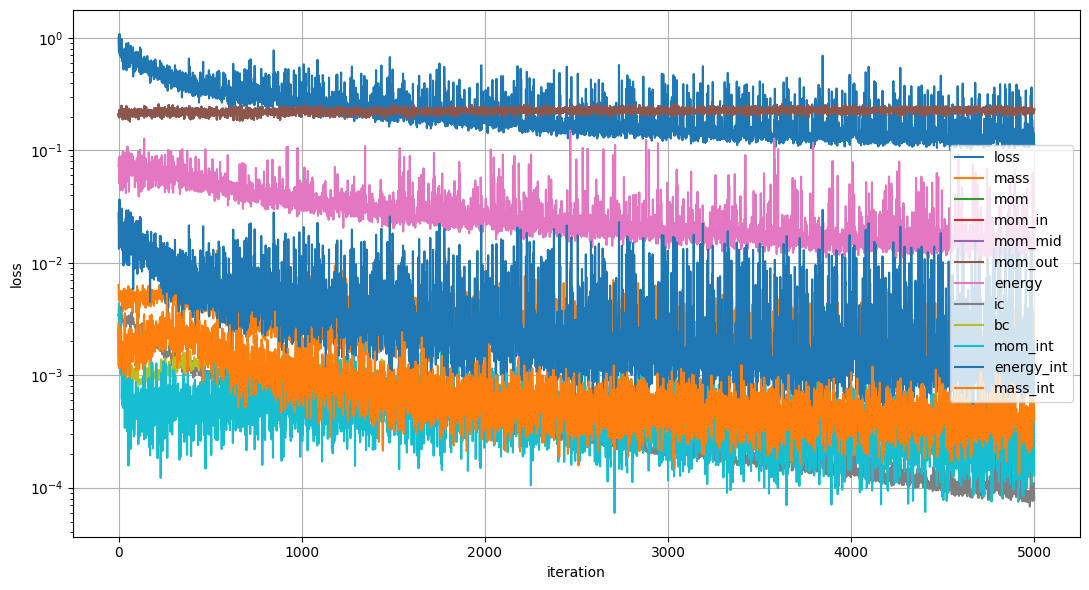

In [55]:
def plot_history(history):
    df = pd.DataFrame(history)

    keys = [
        "loss",
        "mass",
        "mom",
        "mom_in",
        "mom_mid",
        "mom_out",
        "energy",
        "ic",
        "bc",
        "mom_int",
        "energy_int",
        "mass_int",
    ]

    plt.figure(figsize=(11, 6))

    for key in keys:
        if key in df:
            plt.semilogy(df[key].to_numpy(), label=key)

    plt.xlabel("iteration")
    plt.ylabel("loss")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_history(history)

In [56]:
@torch.no_grad()
def validate(model, physics, case, forcing, device, dtype=torch.float32):
    model.eval()

    tau = torch.tensor(forcing.tau.copy(), device=device, dtype=dtype).reshape(-1, 1)
    t = tau * case.w0 / case.L

    z_in = torch.zeros_like(t)
    z_out = torch.ones_like(t)

    G_in, _, pi_in, _, _, _ = physics.fields(z_in, t)
    G_out, _, pi_out, _, _, _ = physics.fields(z_out, t)

    flow_in_pinn = case.A * case.rho_pc * case.w0 * G_in
    flow_out_pinn = case.A * case.rho_pc * case.w0 * G_out

    Q = torch.tensor(forcing.power.copy(), device=device, dtype=dtype).reshape(-1, 1)

    ntpc_pinn = (
        case.beta_pc
        / case.Cp_pc
        * Q
        / flow_in_pinn
    )

    model.train()

    return {
        "time": forcing.time,
        "flow_in_base": forcing.flow_in,
        "flow_out_base": forcing.flow_out,
        "ntpc_base": forcing.ntpc,
        "flow_in_pinn": flow_in_pinn.cpu().numpy().reshape(-1),
        "flow_out_pinn": flow_out_pinn.cpu().numpy().reshape(-1),
        "ntpc_pinn": ntpc_pinn.cpu().numpy().reshape(-1),
        "pi_in_pinn": pi_in.cpu().numpy().reshape(-1),
        "pi_out_pinn": pi_out.cpu().numpy().reshape(-1),
        "pi_in_target": np.full_like(forcing.time, case.dpi_star, dtype=float),
        "pi_out_target": np.zeros_like(forcing.time, dtype=float),
    }


val = validate(model, physics, case, forcing, device, dtype)

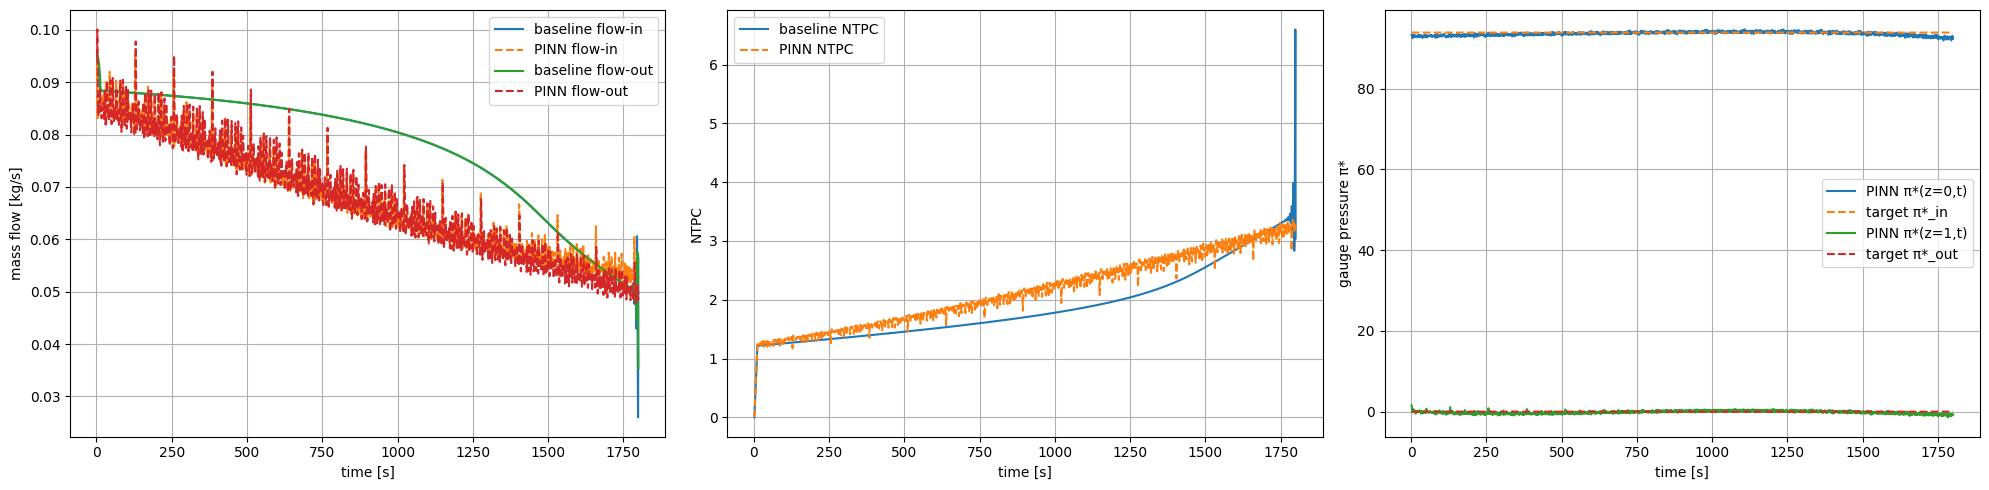

In [57]:
def plot_validation(val):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    ax = axes[0]
    ax.plot(val["time"], val["flow_in_base"], label="baseline flow-in")
    ax.plot(val["time"], val["flow_in_pinn"], "--", label="PINN flow-in")

    ax.plot(val["time"], val["flow_out_base"], label="baseline flow-out")
    ax.plot(val["time"], val["flow_out_pinn"], "--", label="PINN flow-out")

    ax.set_xlabel("time [s]")
    ax.set_ylabel("mass flow [kg/s]")
    ax.grid(True)
    ax.legend()

    ax = axes[1]
    ax.plot(val["time"], val["ntpc_base"], label="baseline NTPC")
    ax.plot(val["time"], val["ntpc_pinn"], "--", label="PINN NTPC")

    ax.set_xlabel("time [s]")
    ax.set_ylabel("NTPC")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(val["time"], val["pi_in_pinn"], label="PINN π*(z=0,t)")
    ax.plot(val["time"], val["pi_in_target"], "--", label="target π*_in")

    ax.plot(val["time"], val["pi_out_pinn"], label="PINN π*(z=1,t)")
    ax.plot(val["time"], val["pi_out_target"], "--", label="target π*_out")

    ax.set_xlabel("time [s]")
    ax.set_ylabel("gauge pressure π*")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_validation(val)

QS solved: 17169/17169 times (nan=0)
QS flow: first=0.08959  last=0.03746 kg/s


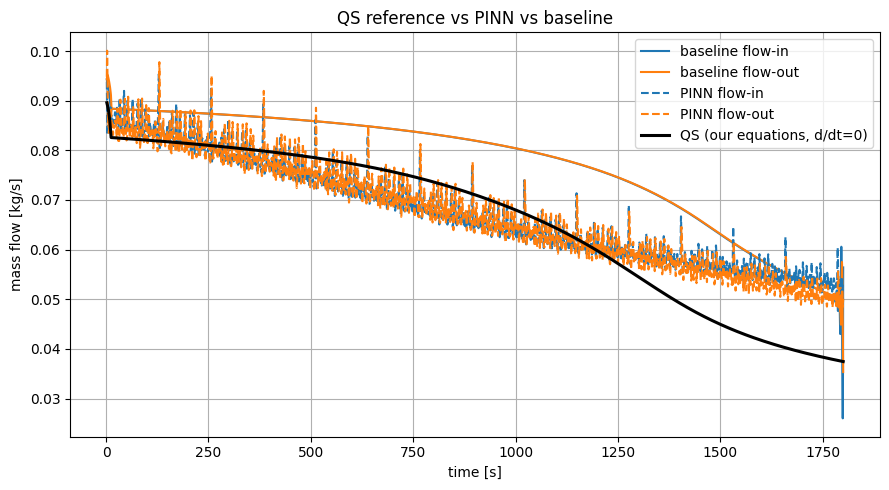

In [58]:
# QS (quasi-steady) reference curve -- independent yardstick, NOT in the loss.
# Solves OUR OWN equations in the d/dt=0 limit: for each time t we root-find a
# constant-in-z flow G*(t) such that the integrated momentum balance equals the
# imposed Delta pi*. Enthalpy from the steady energy balance G* h*_z = NQ'(t) ->
# h*(z) = -nspc + (NQ'/G*) z; density from the EOS. Uses ONLY the forcing Q(t),
# the imposed Delta p, h_in and the EOS -- the baseline is never touched, so this
# respects the pure-forward / no-data-driven principle. The PINN, if it actually
# solved these equations, must track this curve on the slow (non-oscillatory)
# part of the transient; the residual gap PINN-vs-baseline is then the honest
# code-to-code (A2) difference, not a PINN error. Density-wave oscillations (B)
# are steady-state-absent by construction and will NOT appear here.
@torch.no_grad()
def qs_flow_curve(physics, case, forcing, device, dtype=torch.float32,
                  n_z=401, n_bisect=60):
    z = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype).reshape(-1, 1)
    zf = z.reshape(-1)
    di = delta_inlet(z, physics.alpha).reshape(-1)
    do = delta_outlet(z, physics.alpha).reshape(-1)

    def mom_rhs(Gstar, t_val):
        # Sum of momentum terms for a constant-in-z flow Gstar at time t_val.
        # accel = integral G_t dz = 0 (steady), so it is dropped. Everything else
        # matches integral_mom_loss / pressure_budget, rho anchored at end faces.
        t_col = torch.full_like(z, t_val)
        NQp0 = physics.NQ_prime(t_col)[0, 0]
        h = -case.nspc + (NQp0 / Gstar) * z              # steady enthalpy profile
        rho, _ = physics.eos25(h)
        G = torch.full_like(z, float(Gstar))
        flux = G ** 2 / rho
        Lam, slf, _, _ = physics.distributed_friction(G=G, h=h, rho=rho)
        gg = (G * smooth_abs(G, eps=1e-6)).reshape(-1)   # G|G|
        flux_jump = flux[-1, 0] - flux[0, 0]
        gravity = torch.trapezoid((rho / case.Fr).reshape(-1), zf)
        friction = torch.trapezoid((Lam * slf).reshape(-1), zf)
        local_in = torch.trapezoid(0.5 * case.kin * di * gg / rho[0, 0], zf)
        local_out = torch.trapezoid(0.5 * case.kout * do * gg / rho[-1, 0], zf)
        return float(flux_jump + gravity + friction + local_in + local_out)

    def solve(t_val):
        # rhs increases monotonically with Gstar (G^2 terms dominate), so a plain
        # bisection on rhs(Gstar) - dpi_star is robust.
        a, b = 1e-3 * case.G0_star, 6.0 * case.G0_star
        fa = mom_rhs(a, t_val) - case.dpi_star
        fb = mom_rhs(b, t_val) - case.dpi_star
        if fa * fb > 0:
            return float("nan")                          # no bracket -> flag it
        for _ in range(n_bisect):
            m = 0.5 * (a + b)
            fm = mom_rhs(m, t_val) - case.dpi_star
            if (fm > 0) == (fb > 0):
                b = m
            else:
                a = m
        return 0.5 * (a + b)

    tau = np.asarray(forcing.tau, dtype=float)
    t_star = tau * case.w0 / case.L
    G_qs = np.array([solve(float(ts)) for ts in t_star])
    flow_qs = case.A * case.rho_pc * case.w0 * G_qs
    return {"time": forcing.time, "t_star": t_star, "G_qs": G_qs, "flow_qs": flow_qs}


qs = qs_flow_curve(physics, case, forcing, device, dtype)
n_nan = int(np.isnan(qs["G_qs"]).sum())
print(f"QS solved: {len(qs['G_qs']) - n_nan}/{len(qs['G_qs'])} times (nan={n_nan})")
print(f"QS flow: first={qs['flow_qs'][0]:.5f}  last={qs['flow_qs'][-1]:.5f} kg/s")


def plot_qs_vs_pinn(val, qs):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(val["time"], val["flow_in_base"], color="C0", label="baseline flow-in")
    ax.plot(val["time"], val["flow_out_base"], color="C1", label="baseline flow-out")
    ax.plot(val["time"], val["flow_in_pinn"], "--", color="C0", label="PINN flow-in")
    ax.plot(val["time"], val["flow_out_pinn"], "--", color="C1", label="PINN flow-out")
    ax.plot(qs["time"], qs["flow_qs"], color="k", lw=2.2,
            label="QS (our equations, d/dt=0)")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("mass flow [kg/s]")
    ax.set_title("QS reference vs PINN vs baseline")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_qs_vs_pinn(val, qs)


In [59]:
def rmse(a, b):
    a = np.asarray(a)
    b = np.asarray(b)

    return float(np.sqrt(np.mean((a - b) ** 2)))


print("RMSE flow-in :", rmse(val["flow_in_base"], val["flow_in_pinn"]))
print("RMSE flow-out:", rmse(val["flow_out_base"], val["flow_out_pinn"]))
print("RMSE NTPC    :", rmse(val["ntpc_base"], val["ntpc_pinn"]))

RMSE flow-in : 0.011638265572960492
RMSE flow-out: 0.01136287473674545
RMSE NTPC    : 0.341670212874253


In [60]:
@torch.no_grad()
def boundary_field_stats(model, physics, case, forcing, device, dtype=torch.float32):
    model.eval()

    tau = torch.as_tensor(forcing.tau, device=device, dtype=dtype).reshape(-1, 1)
    t = tau * case.w0 / case.L

    z0 = torch.zeros_like(t)
    z1 = torch.ones_like(t)

    G0, h0, pi0, Ghat0, hhat0, Pihat0 = physics.fields(z0, t)
    G1, h1, pi1, Ghat1, hhat1, Pihat1 = physics.fields(z1, t)

    def stat(name, x):
        x = x.detach().cpu().numpy().reshape(-1)
        print(
            f"{name:14s}: "
            f"min={x.min(): .4e}, "
            f"mean={x.mean(): .4e}, "
            f"max={x.max(): .4e}, "
            f"std={x.std(): .4e}"
        )

    print("=== TARGETS ===")
    print(f"G0*        = {case.G0_star:.6e}")
    print(f"h_in*      = {case.h0_star:.6e}")
    print(f"pi_in*     = {case.dpi_star:.6e}")
    print(f"pi_out*    = 0")
    print()

    print("=== PHYSICAL SCALED FIELDS ===")
    stat("G(z=0)", G0)
    stat("G(z=1)", G1)
    stat("h(z=0)", h0)
    stat("h(z=1)", h1)
    stat("pi(z=0)", pi0)
    stat("pi(z=1)", pi1)

    print()
    print("=== RAW NETWORK OUTPUTS ===")
    stat("G_hat(z=0)", Ghat0)
    stat("G_hat(z=1)", Ghat1)
    stat("h_hat(z=0)", hhat0)
    stat("h_hat(z=1)", hhat1)
    stat("Pi_hat(z=0)", Pihat0)
    stat("Pi_hat(z=1)", Pihat1)

    model.train()


boundary_field_stats(model, physics, case, forcing, device, dtype)

=== TARGETS ===
G0*        = 2.698876e+00
h_in*      = -2.000000e+00
pi_in*     = 9.385098e+01
pi_out*    = 0

=== PHYSICAL SCALED FIELDS ===
G(z=0)        : min= 1.4601e+00, mean= 1.9081e+00, max= 2.7281e+00, std= 2.7605e-01
G(z=1)        : min= 1.3602e+00, mean= 1.9069e+00, max= 2.8632e+00, std= 2.9769e-01
h(z=0)        : min=-2.2127e+00, mean=-2.0042e+00, max=-1.9190e+00, std= 3.0058e-02
h(z=1)        : min=-2.0028e+00, mean= 2.0049e-01, max= 1.2846e+00, std= 5.6375e-01
pi(z=0)       : min= 9.1895e+01, mean= 9.3614e+01, max= 9.4638e+01, std= 4.2869e-01
pi(z=1)       : min=-1.4006e+00, mean=-1.3714e-01, max= 1.5693e+00, std= 3.3312e-01

=== RAW NETWORK OUTPUTS ===
G_hat(z=0)    : min= 5.4102e-01, mean= 7.0698e-01, max= 1.0108e+00, std= 1.0228e-01
G_hat(z=1)    : min= 5.0400e-01, mean= 7.0657e-01, max= 1.0609e+00, std= 1.1030e-01
h_hat(z=0)    : min=-1.1064e+00, mean=-1.0021e+00, max=-9.5952e-01, std= 1.5029e-02
h_hat(z=1)    : min=-1.0014e+00, mean= 1.0025e-01, max= 6.4231e-01, std= 

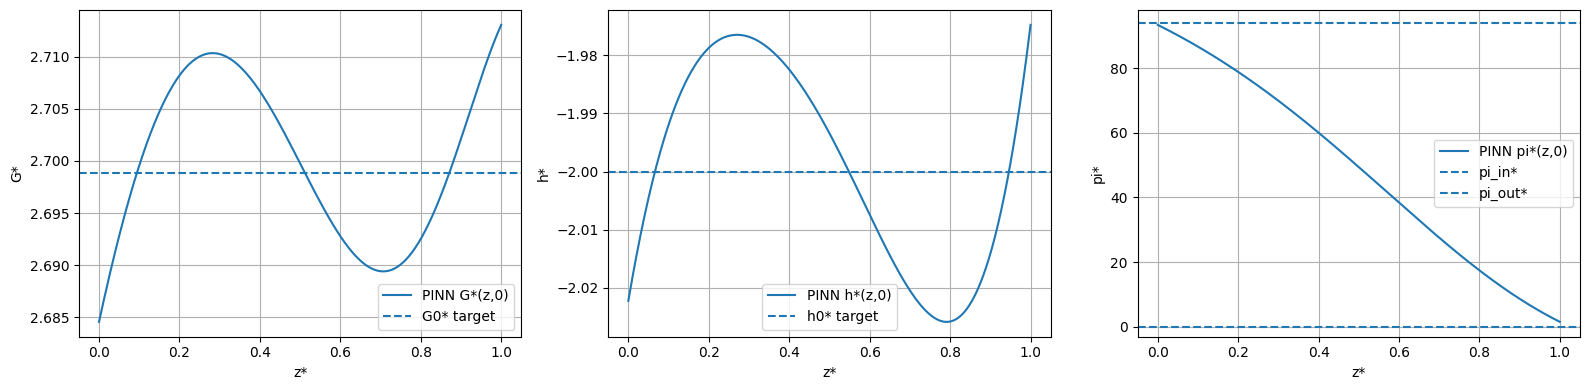

In [61]:
@torch.no_grad()
def plot_ic_profiles(model, physics, case, device, dtype=torch.float32):
    model.eval()

    z = torch.linspace(0, 1, 400, device=device, dtype=dtype).reshape(-1, 1)
    t = torch.zeros_like(z)

    G, h, pi, _, _, _ = physics.fields(z, t)

    z_np = z.cpu().numpy().reshape(-1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(z_np, G.cpu().numpy().reshape(-1), label="PINN G*(z,0)")
    axes[0].axhline(case.G0_star, linestyle="--", label="G0* target")
    axes[0].set_xlabel("z*")
    axes[0].set_ylabel("G*")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(z_np, h.cpu().numpy().reshape(-1), label="PINN h*(z,0)")
    axes[1].axhline(case.h0_star, linestyle="--", label="h0* target")
    axes[1].set_xlabel("z*")
    axes[1].set_ylabel("h*")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(z_np, pi.cpu().numpy().reshape(-1), label="PINN pi*(z,0)")
    axes[2].axhline(case.dpi_star, linestyle="--", label="pi_in*")
    axes[2].axhline(0.0, linestyle="--", label="pi_out*")
    axes[2].set_xlabel("z*")
    axes[2].set_ylabel("pi*")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    model.train()


plot_ic_profiles(model, physics, case, device, dtype)

In [62]:
def normalized_error_report(history):
    last = history[-1]

    print("=== NORMALIZED ERROR REPORT ===")

    for key in [
        "ic_G",
        "ic_h",
        "bc_h_in",
        "bc_dp",
        "bc_pi_out",
        "mass",
        "mom",
        "energy",
    ]:
        if key in last:
            print(f"{key:12s}: RMS = {math.sqrt(last[key]):.6e}, MSE = {last[key]:.6e}")


normalized_error_report(history)

=== NORMALIZED ERROR REPORT ===
ic_G        : RMS = 4.047226e-03, MSE = 1.638004e-05
ic_h        : RMS = 7.835090e-03, MSE = 6.138864e-05
bc_h_in     : RMS = 1.638254e-02, MSE = 2.683876e-04
bc_dp       : RMS = 3.643338e-03, MSE = 1.327391e-05
bc_pi_out   : RMS = 4.537152e-03, MSE = 2.058575e-05
mass        : RMS = 3.906836e-02, MSE = 1.526337e-03
mom         : RMS = 4.798940e-01, MSE = 2.302982e-01
energy      : RMS = 1.118063e-01, MSE = 1.250064e-02


In [63]:
@torch.no_grad()
def eval_fields_on_grid(model, physics, case, device, dtype=torch.float32, n_z=201, n_t=300):
    model.eval()

    z = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype)
    t = torch.linspace(0.0, case.t_end_star, n_t, device=device, dtype=dtype)

    Z, T = torch.meshgrid(z, t, indexing="ij")

    zz = Z.reshape(-1, 1)
    tt = T.reshape(-1, 1)

    G, h, pi, _, _, _ = physics.fields(zz, tt)
    rho, chi_h = physics.eos25(h)

    out = {
        "z": z.cpu().numpy(),
        "t_star": t.cpu().numpy(),
        "time_s": (t.cpu().numpy() * case.L / case.w0) + 2.0,
        "G": G.cpu().numpy().reshape(n_z, n_t),
        "h": h.cpu().numpy().reshape(n_z, n_t),
        "pi": pi.cpu().numpy().reshape(n_z, n_t),
        "rho": rho.cpu().numpy().reshape(n_z, n_t),
        "chi_h": chi_h.cpu().numpy().reshape(n_z, n_t),
    }

    model.train()
    return out


grid = eval_fields_on_grid(
    model=model,
    physics=physics,
    case=case,
    device=device,
    dtype=dtype,
    n_z=201,
    n_t=300,
)

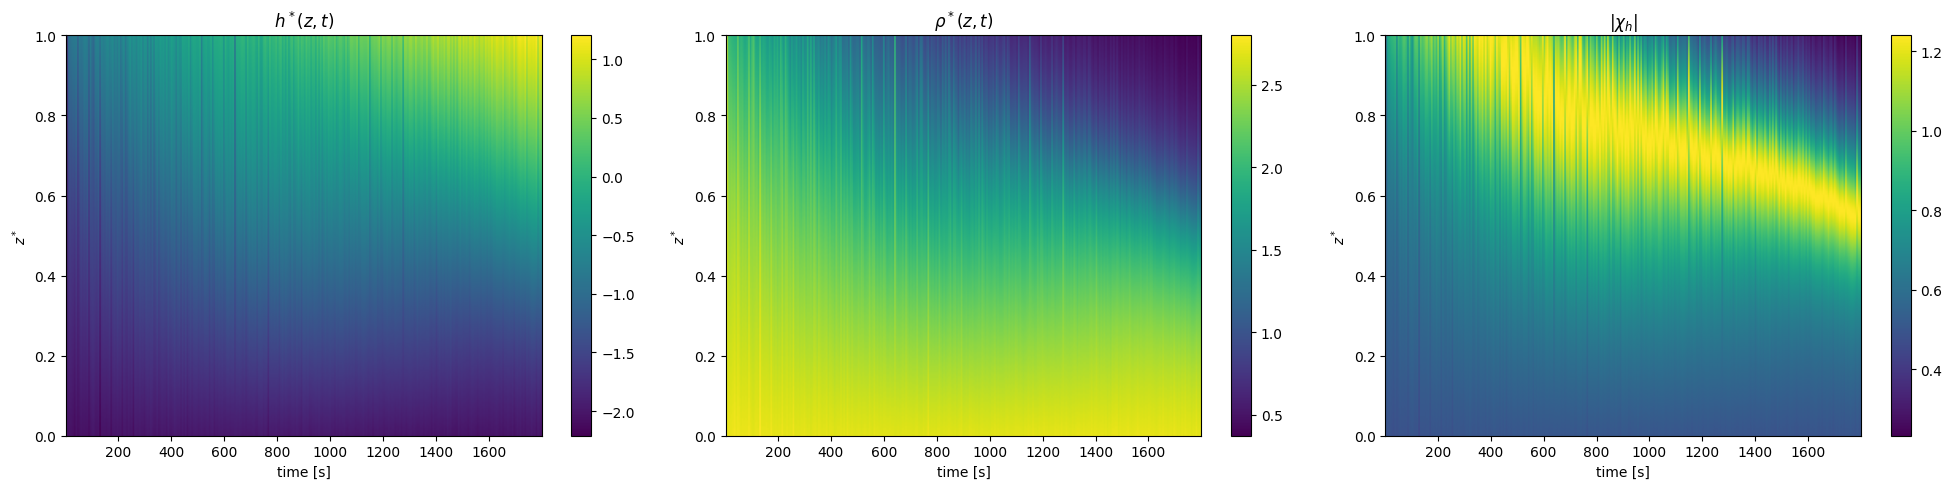

In [64]:
def plot_heatmaps(grid):
    z = grid["z"]
    time = grid["time_s"]

    fields = [
        ("h", r"$h^*(z,t)$"),
        ("rho", r"$\rho^*(z,t)$"),
        ("chi_h", r"$\chi_h=d\rho^*/dh^*$"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    for ax, (key, title) in zip(axes, fields):
        data = grid[key]

        if key == "chi_h":
            data = np.abs(data)
            title = r"$|\chi_h|$"

        im = ax.imshow(
            data,
            origin="lower",
            aspect="auto",
            extent=[time.min(), time.max(), z.min(), z.max()],
        )

        ax.set_title(title)
        ax.set_xlabel("time [s]")
        ax.set_ylabel(r"$z^*$")
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()


plot_heatmaps(grid)

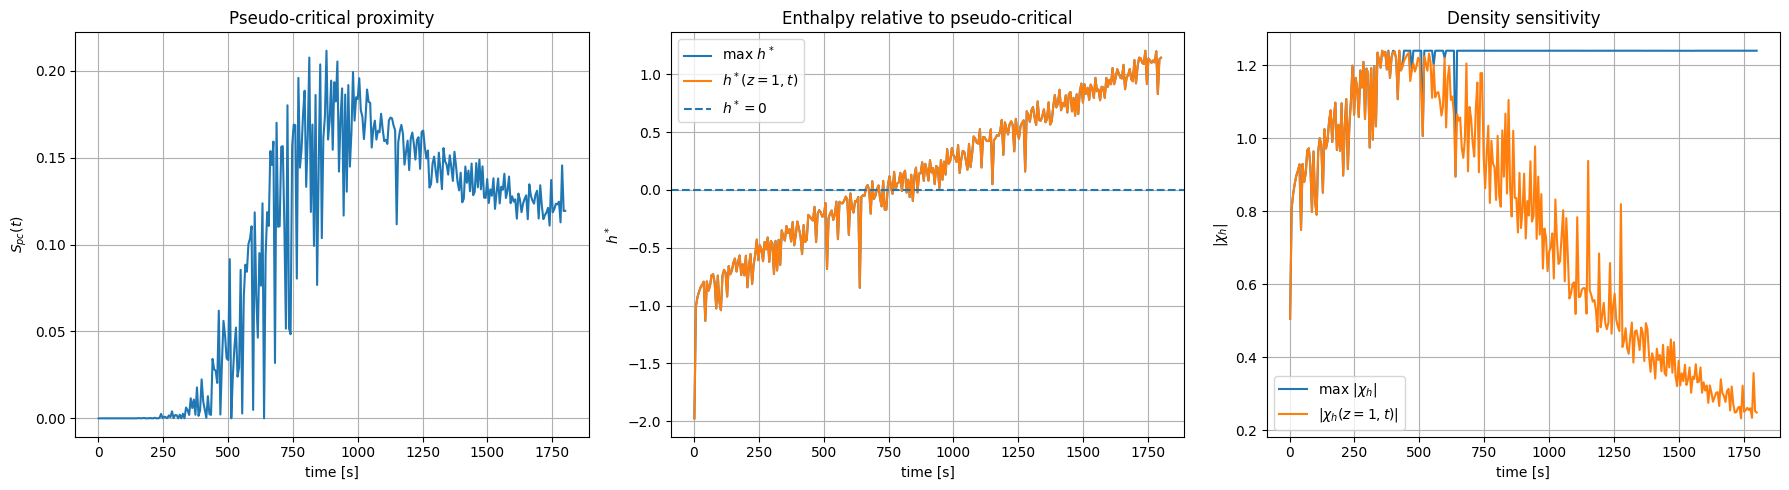

In [65]:
def pseudo_critical_indicator(grid, sigma_h=0.25):
    z = grid["z"]
    h = grid["h"]
    chi_h = grid["chi_h"]

    kernel = np.exp(-(h / sigma_h) ** 2)

    S_pc = np.trapezoid(kernel, z, axis=0)
    h_max = h.max(axis=0)
    h_out = h[-1, :]
    chi_max = np.max(np.abs(chi_h), axis=0)
    chi_out = np.abs(chi_h[-1, :])

    return {
        "time": grid["time_s"],
        "S_pc": S_pc,
        "h_max": h_max,
        "h_out": h_out,
        "chi_max": chi_max,
        "chi_out": chi_out,
    }


pc = pseudo_critical_indicator(grid, sigma_h=0.25)


def plot_pseudo_critical_indicator(pc):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(pc["time"], pc["S_pc"])
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$S_{pc}(t)$")
    ax.set_title("Pseudo-critical proximity")
    ax.grid(True)

    ax = axes[1]
    ax.plot(pc["time"], pc["h_max"], label=r"max $h^*$")
    ax.plot(pc["time"], pc["h_out"], label=r"$h^*(z=1,t)$")
    ax.axhline(0.0, linestyle="--", label=r"$h^*=0$")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$h^*$")
    ax.set_title("Enthalpy relative to pseudo-critical")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(pc["time"], pc["chi_max"], label=r"max $|\chi_h|$")
    ax.plot(pc["time"], pc["chi_out"], label=r"$|\chi_h(z=1,t)|$")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$|\chi_h|$")
    ax.set_title("Density sensitivity")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_pseudo_critical_indicator(pc)

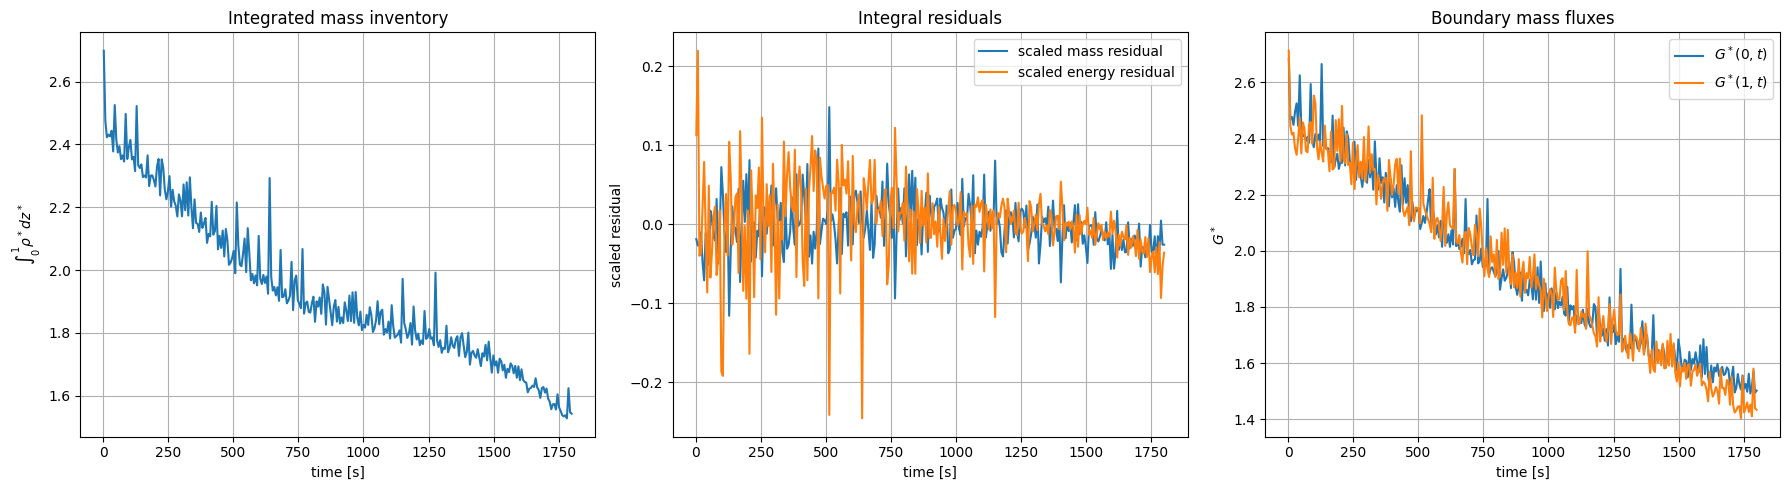

Integral mass residual RMS: 0.03217765
Integral energy residual RMS: 0.052486368


In [66]:
@torch.no_grad()
def integral_residuals(grid, physics, case, forcing, device, dtype=torch.float32):
    z = grid["z"]
    t_star = grid["t_star"]
    time = grid["time_s"]

    G = grid["G"]
    h = grid["h"]
    rho = grid["rho"]

    mass_int = np.trapezoid(rho, z, axis=0)
    energy_int = np.trapezoid(rho * h, z, axis=0)

    dmass_dt = np.gradient(mass_int, t_star)
    denergy_dt = np.gradient(energy_int, t_star)

    G_in = G[0, :]
    G_out = G[-1, :]

    Gh_in = G[0, :] * h[0, :]
    Gh_out = G[-1, :] * h[-1, :]

    t_tensor = torch.tensor(t_star.copy(), device=device, dtype=dtype).reshape(-1, 1)
    NQ = physics.NQ_prime(t_tensor).detach().cpu().numpy().reshape(-1)

    R_mass_int = dmass_dt + G_out - G_in
    R_energy_int = denergy_dt + Gh_out - Gh_in - NQ

    return pd.DataFrame({
        "time": time,
        "mass_int": mass_int,
        "energy_int": energy_int,
        "R_mass_int": R_mass_int,
        "R_energy_int": R_energy_int,
        "R_mass_int_scaled": R_mass_int / case.mass_scale,
        "R_energy_int_scaled": R_energy_int / case.energy_scale,
        "G_in": G_in,
        "G_out": G_out,
        "NQ": NQ,
    })


int_res = integral_residuals(grid, physics, case, forcing, device, dtype)


def plot_integral_residuals(int_res):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(int_res["time"], int_res["mass_int"])
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$\int_0^1 \rho^* dz^*$")
    ax.set_title("Integrated mass inventory")
    ax.grid(True)

    ax = axes[1]
    ax.plot(int_res["time"], int_res["R_mass_int_scaled"], label="scaled mass residual")
    ax.plot(int_res["time"], int_res["R_energy_int_scaled"], label="scaled energy residual")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("scaled residual")
    ax.set_title("Integral residuals")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(int_res["time"], int_res["G_in"], label=r"$G^*(0,t)$")
    ax.plot(int_res["time"], int_res["G_out"], label=r"$G^*(1,t)$")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$G^*$")
    ax.set_title("Boundary mass fluxes")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_integral_residuals(int_res)

print("Integral mass residual RMS:", np.sqrt(np.mean(int_res["R_mass_int_scaled"] ** 2)))
print("Integral energy residual RMS:", np.sqrt(np.mean(int_res["R_energy_int_scaled"] ** 2)))

In [67]:
def pressure_budget(model, physics, case, device, dtype=torch.float32, n_z=401, n_t=200):
    model.train()

    z_base = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype).reshape(-1, 1)
    t_vals = torch.linspace(0.0, case.t_end_star, n_t, device=device, dtype=dtype)

    rows = []

    for t0 in t_vals:
        z = z_base.clone().detach().requires_grad_(True)
        t = torch.full_like(z, t0.item()).requires_grad_(True)

        G, h, pi, _, _, _ = physics.fields(z, t)
        rho, _ = physics.eos25(h)

        G_t = d(G, t)

        flux = G**2 / rho

        delta0 = delta_inlet(z, physics.alpha)
        delta1 = delta_outlet(z, physics.alpha)

        accel = torch.trapezoid(G_t.reshape(-1), z.reshape(-1))
        flux_jump = flux[-1, 0] - flux[0, 0]
        gravity = torch.trapezoid((rho / case.Fr).reshape(-1), z.reshape(-1))

        Lambda_dyn, signed_loss_flux, Re, lambda_darcy = physics.distributed_friction(
            G=G,
            h=h,
            rho=rho,
        )

        friction_dist = torch.trapezoid(
            (Lambda_dyn * signed_loss_flux).reshape(-1),
            z.reshape(-1),
        )

        # Match residuals_raw: anchor the local-loss density at the end faces
        # (rho[0] at inlet, rho[-1] at outlet) instead of using signed_loss_flux,
        # which carries the local rho(z) smeared by the Gaussian.
        loss_flux_num = (G * smooth_abs(G, eps=1e-6)).reshape(-1)  # G|G|

        local_in = torch.trapezoid(
            0.5 * case.kin * delta_inlet(z, physics.alpha).reshape(-1)
            * loss_flux_num / rho[0, 0],
            z.reshape(-1),
        )

        local_out = torch.trapezoid(
            0.5 * case.kout * delta_outlet(z, physics.alpha).reshape(-1)
            * loss_flux_num / rho[-1, 0],
            z.reshape(-1),
        )

        pressure_drop = pi[0, 0] - pi[-1, 0]

        rhs = accel + flux_jump + gravity + friction_dist + local_in + local_out
        residual = rhs - pressure_drop

        rows.append({
            "t_star": float(t0.detach().cpu()),
            "time": float(t0.detach().cpu()) * case.L / case.w0 + 2.0,
            "pressure_drop": float(pressure_drop.detach().cpu()),
            "accel": float(accel.detach().cpu()),
            "flux_jump": float(flux_jump.detach().cpu()),
            "gravity": float(gravity.detach().cpu()),
            "friction_dist": float(friction_dist.detach().cpu()),
            "local_in": float(local_in.detach().cpu()),
            "local_out": float(local_out.detach().cpu()),
            "rhs": float(rhs.detach().cpu()),
            "budget_residual": float(residual.detach().cpu()),
        })

    return pd.DataFrame(rows)


budget = pressure_budget(
    model=model,
    physics=physics,
    case=case,
    device=device,
    dtype=dtype,
    n_z=401,
    n_t=200,
)

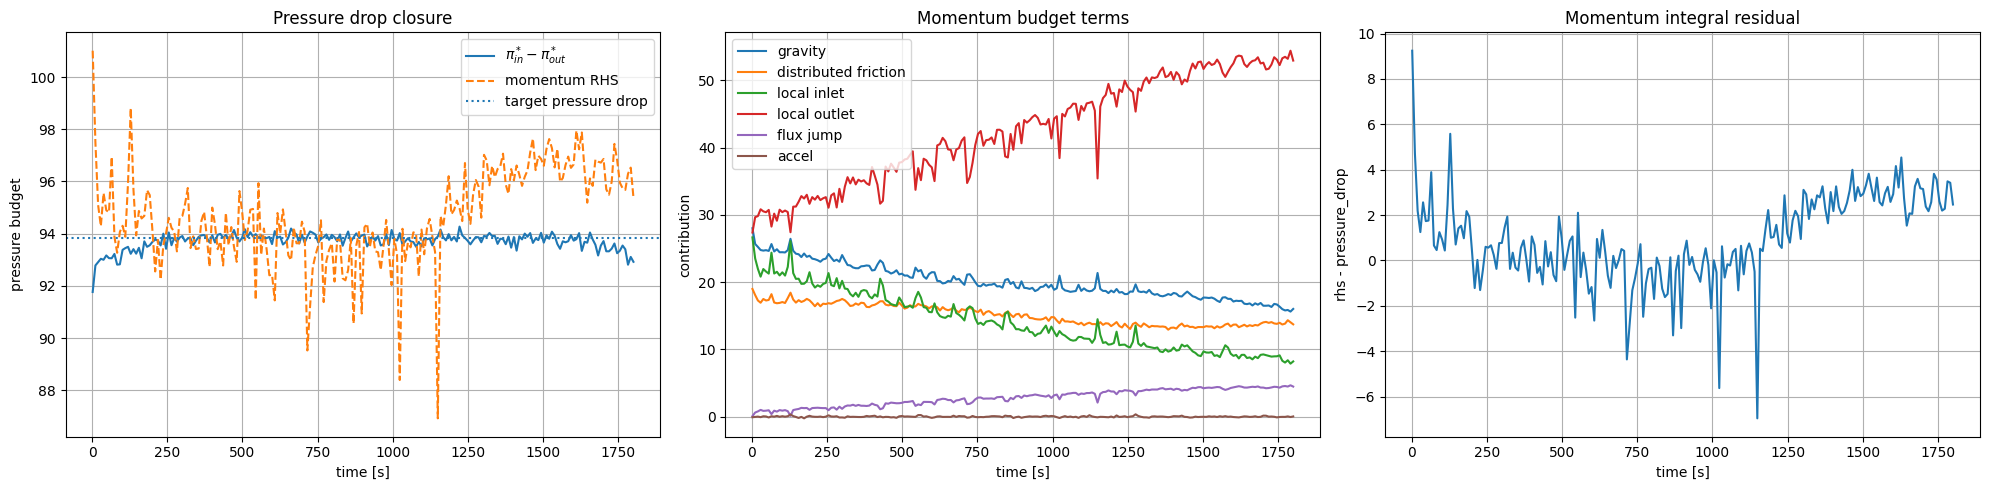

Pressure budget residual RMS: 2.1532328327947954
Mean pressure drop: 93.70766414642334
Target pressure drop: 93.85097958770776


In [68]:
def plot_pressure_budget(budget):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    ax = axes[0]
    ax.plot(budget["time"], budget["pressure_drop"], label=r"$\pi_{in}^*-\pi_{out}^*$")
    ax.plot(budget["time"], budget["rhs"], "--", label="momentum RHS")
    ax.axhline(case.dpi_star, linestyle=":", label="target pressure drop")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("pressure budget")
    ax.set_title("Pressure drop closure")
    ax.grid(True)
    ax.legend()

    ax = axes[1]
    ax.plot(budget["time"], budget["gravity"], label="gravity")
    ax.plot(budget["time"], budget["friction_dist"], label="distributed friction")
    ax.plot(budget["time"], budget["local_in"], label="local inlet")
    ax.plot(budget["time"], budget["local_out"], label="local outlet")
    ax.plot(budget["time"], budget["flux_jump"], label="flux jump")
    ax.plot(budget["time"], budget["accel"], label="accel")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("contribution")
    ax.set_title("Momentum budget terms")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(budget["time"], budget["budget_residual"])
    ax.set_xlabel("time [s]")
    ax.set_ylabel("rhs - pressure_drop")
    ax.set_title("Momentum integral residual")
    ax.grid(True)

    plt.tight_layout()
    plt.show()


plot_pressure_budget(budget)

print("Pressure budget residual RMS:", np.sqrt(np.mean(budget["budget_residual"] ** 2)))
print("Mean pressure drop:", budget["pressure_drop"].mean())
print("Target pressure drop:", case.dpi_star)

In [69]:
def summarize_early_late(grid, int_res, budget, split_time=1100.0):
    time = grid["time_s"]

    early = time < split_time
    late = time >= split_time

    def mean_range(name, arr):
        return {
            f"{name}_early_mean": float(np.mean(arr[early])),
            f"{name}_late_mean": float(np.mean(arr[late])),
            f"{name}_early_min": float(np.min(arr[early])),
            f"{name}_late_min": float(np.min(arr[late])),
            f"{name}_early_max": float(np.max(arr[early])),
            f"{name}_late_max": float(np.max(arr[late])),
        }

    pc = pseudo_critical_indicator(grid)

    rows = {}
    rows.update(mean_range("S_pc", pc["S_pc"]))
    rows.update(mean_range("h_out", pc["h_out"]))
    rows.update(mean_range("chi_max", pc["chi_max"]))

    b_early = budget["time"] < split_time
    b_late = budget["time"] >= split_time

    for col in [
        "pressure_drop",
        "gravity",
        "friction_dist",
        "local_in",
        "local_out",
        "accel",
        "flux_jump",
        "budget_residual",
    ]:
        rows[f"{col}_early_mean"] = float(budget.loc[b_early, col].mean())
        rows[f"{col}_late_mean"] = float(budget.loc[b_late, col].mean())

    i_early = int_res["time"] < split_time
    i_late = int_res["time"] >= split_time

    rows["R_mass_int_early_rms"] = float(np.sqrt(np.mean(int_res.loc[i_early, "R_mass_int_scaled"] ** 2)))
    rows["R_mass_int_late_rms"] = float(np.sqrt(np.mean(int_res.loc[i_late, "R_mass_int_scaled"] ** 2)))

    rows["R_energy_int_early_rms"] = float(np.sqrt(np.mean(int_res.loc[i_early, "R_energy_int_scaled"] ** 2)))
    rows["R_energy_int_late_rms"] = float(np.sqrt(np.mean(int_res.loc[i_late, "R_energy_int_scaled"] ** 2)))

    return pd.DataFrame.from_dict(rows, orient="index", columns=["value"])


summary_late = summarize_early_late(grid, int_res, budget, split_time=1100.0)
summary_late.to_csv("summary_late.csv")

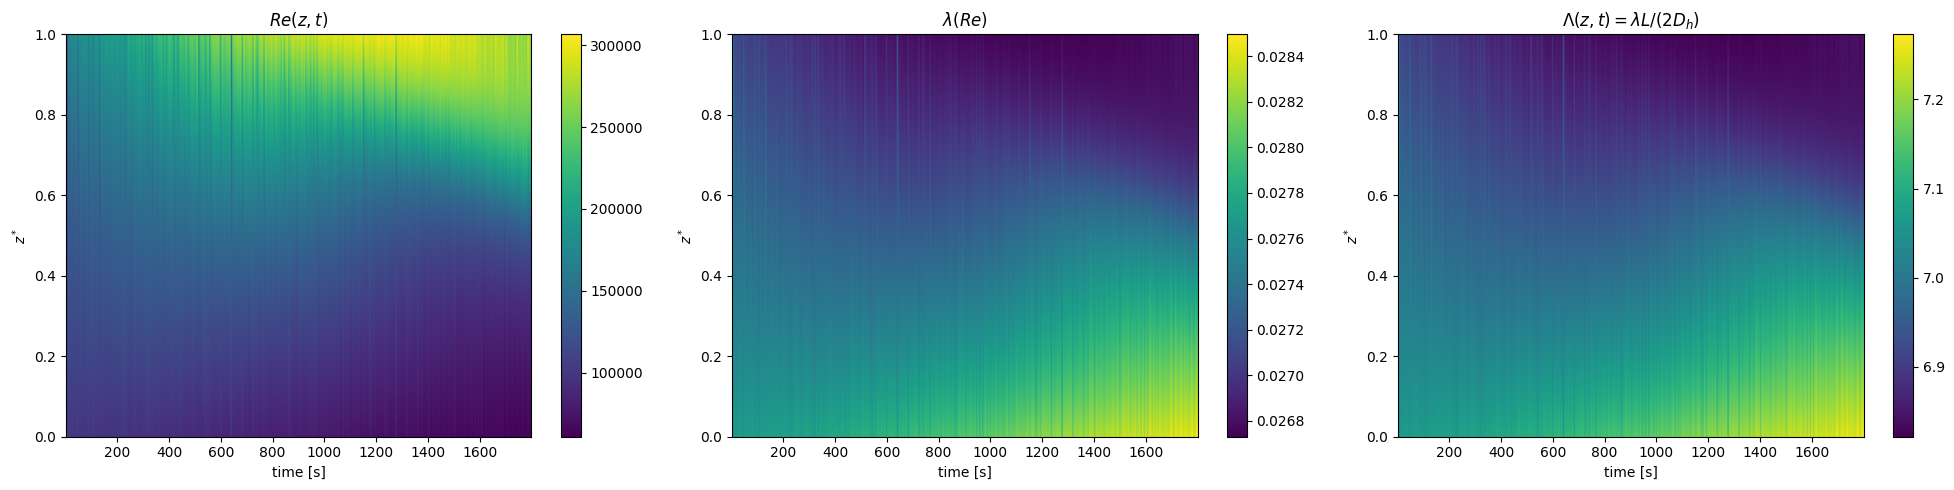

In [70]:
@torch.no_grad()
def friction_diagnostics(model, physics, case, device, dtype=torch.float32, n_z=201, n_t=300):
    model.eval()

    z = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype)
    t = torch.linspace(0.0, case.t_end_star, n_t, device=device, dtype=dtype)

    Z, T = torch.meshgrid(z, t, indexing="ij")

    zz = Z.reshape(-1, 1)
    tt = T.reshape(-1, 1)

    G, h, _, _, _, _ = physics.fields(zz, tt)
    rho, _ = physics.eos25(h)

    Lambda_dyn, _, Re, lambda_darcy = physics.distributed_friction(G, h, rho)

    out = {
        "z": z.cpu().numpy(),
        "time": (t.cpu().numpy() * case.L / case.w0) + 2.0,
        "Re": Re.cpu().numpy().reshape(n_z, n_t),
        "lambda": lambda_darcy.cpu().numpy().reshape(n_z, n_t),
        "Lambda": Lambda_dyn.cpu().numpy().reshape(n_z, n_t),
    }

    model.train()
    return out


def plot_friction_diagnostics(fr):
    z = fr["z"]
    time = fr["time"]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    for ax, key, title in zip(
        axes,
        ["Re", "lambda", "Lambda"],
        [r"$Re(z,t)$", r"$\lambda(Re)$", r"$\Lambda(z,t)=\lambda L/(2D_h)$"],
    ):
        im = ax.imshow(
            fr[key],
            origin="lower",
            aspect="auto",
            extent=[time.min(), time.max(), z.min(), z.max()],
        )

        ax.set_title(title)
        ax.set_xlabel("time [s]")
        ax.set_ylabel(r"$z^*$")
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()


fr = friction_diagnostics(model, physics, case, device, dtype)
plot_friction_diagnostics(fr)

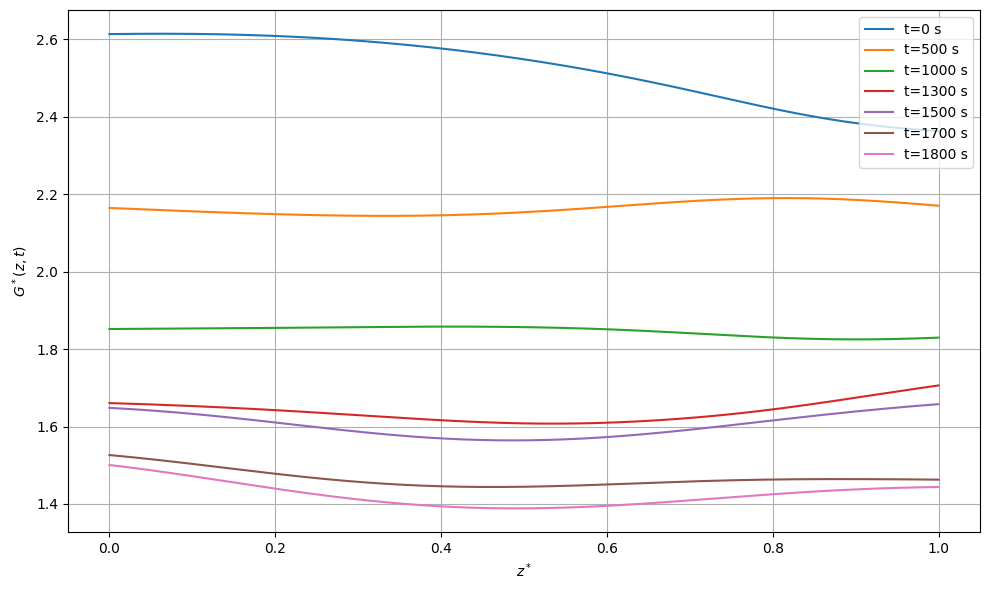

In [71]:
@torch.no_grad()
def plot_G_profiles(model, physics, case, times_s, device, dtype=torch.float32):
    model.eval()

    z = torch.linspace(0.0, 1.0, 400, device=device, dtype=dtype).reshape(-1, 1)

    plt.figure(figsize=(10, 6))

    for ts in times_s:
        t_star = (ts - 2.0) * case.w0 / case.L
        t = torch.full_like(z, t_star)

        G, h, pi, _, _, _ = physics.fields(z, t)

        plt.plot(
            z.cpu().numpy().reshape(-1),
            G.cpu().numpy().reshape(-1),
            label=f"t={ts:.0f} s",
        )

    plt.xlabel(r"$z^*$")
    plt.ylabel(r"$G^*(z,t)$")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    model.train()


plot_G_profiles(
    model=model,
    physics=physics,
    case=case,
    times_s=[0, 500, 1000, 1300, 1500, 1700, 1800],
    device=device,
    dtype=dtype,
)

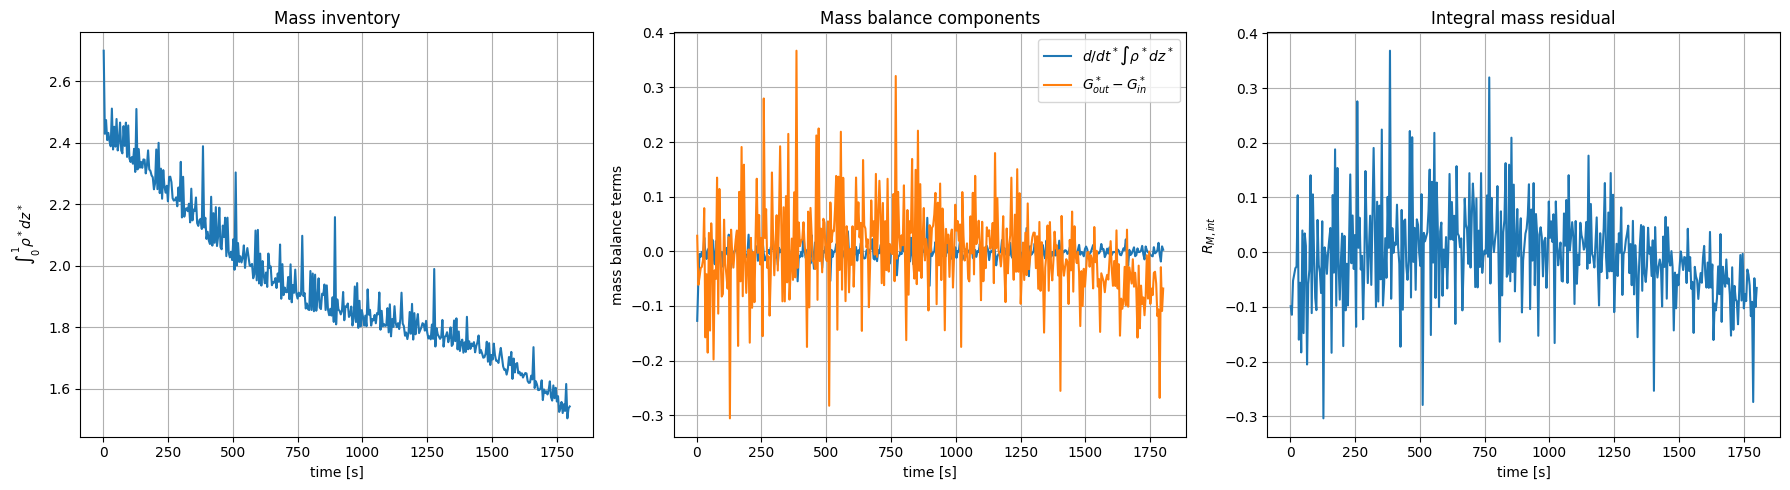

Integral mass RMS: 0.08590496


In [72]:
@torch.no_grad()
def plot_mass_balance_components(grid):
    z = grid["z"]
    t = grid["t_star"]
    time = grid["time_s"]

    rho = grid["rho"]
    G = grid["G"]

    mass_inventory = np.trapezoid(rho, z, axis=0)
    dM_dt = np.gradient(mass_inventory, t)

    G_in = G[0, :]
    G_out = G[-1, :]

    R = dM_dt + G_out - G_in

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(time, mass_inventory)
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$\int_0^1 \rho^* dz^*$")
    ax.set_title("Mass inventory")
    ax.grid(True)

    ax = axes[1]
    ax.plot(time, dM_dt, label=r"$d/dt^* \int \rho^* dz^*$")
    ax.plot(time, G_out - G_in, label=r"$G^*_{out}-G^*_{in}$")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("mass balance terms")
    ax.set_title("Mass balance components")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(time, R)
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$R_{M,int}$")
    ax.set_title("Integral mass residual")
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    print("Integral mass RMS:", np.sqrt(np.mean(R**2)))


grid = eval_fields_on_grid(
    model=model,
    physics=physics,
    case=case,
    device=device,
    dtype=dtype,
    n_z=201,
    n_t=400,
)

plot_mass_balance_components(grid)

In [73]:
@torch.no_grad()
def observe_pinn_extended(
    model,
    physics,
    case,
    forcing,
    device,
    dtype=torch.float32,
    extra_time_s=1000.0,
    n_t=1000,
):
    model.eval()

    time0 = forcing.time[0]
    time1 = forcing.time[-1] + extra_time_s

    time = np.linspace(time0, time1, n_t)
    tau = time - time0

    t_star_np = tau * case.w0 / case.L
    t = torch.tensor(t_star_np.copy(), device=device, dtype=dtype).reshape(-1, 1)

    z_in = torch.zeros_like(t)
    z_out = torch.ones_like(t)

    G_in, h_in, pi_in, _, _, _ = physics.fields(z_in, t)
    G_out, h_out, pi_out, _, _, _ = physics.fields(z_out, t)

    flow_in = case.A * case.rho_pc * case.w0 * G_in
    flow_out = case.A * case.rho_pc * case.w0 * G_out

    # np.interp вне диапазона держит последнее значение power
    Q_np = np.interp(tau, forcing.tau, forcing.power)
    Q = torch.tensor(Q_np.copy(), device=device, dtype=dtype).reshape(-1, 1)

    ntpc = (
        case.beta_pc
        / case.Cp_pc
        * Q
        / flow_in
    )

    model.train()

    return {
        "time": time,
        "flow_in": flow_in.cpu().numpy().reshape(-1),
        "flow_out": flow_out.cpu().numpy().reshape(-1),
        "ntpc": ntpc.cpu().numpy().reshape(-1),
        "h_out": h_out.cpu().numpy().reshape(-1),
        "pi_in": pi_in.cpu().numpy().reshape(-1),
        "pi_out": pi_out.cpu().numpy().reshape(-1),
        "original_time_end": forcing.time[-1],
    }


obs = observe_pinn_extended(
    model=model,
    physics=physics,
    case=case,
    forcing=forcing,
    device=device,
    dtype=dtype,
    extra_time_s=1000.0,
    n_t=1200,
)

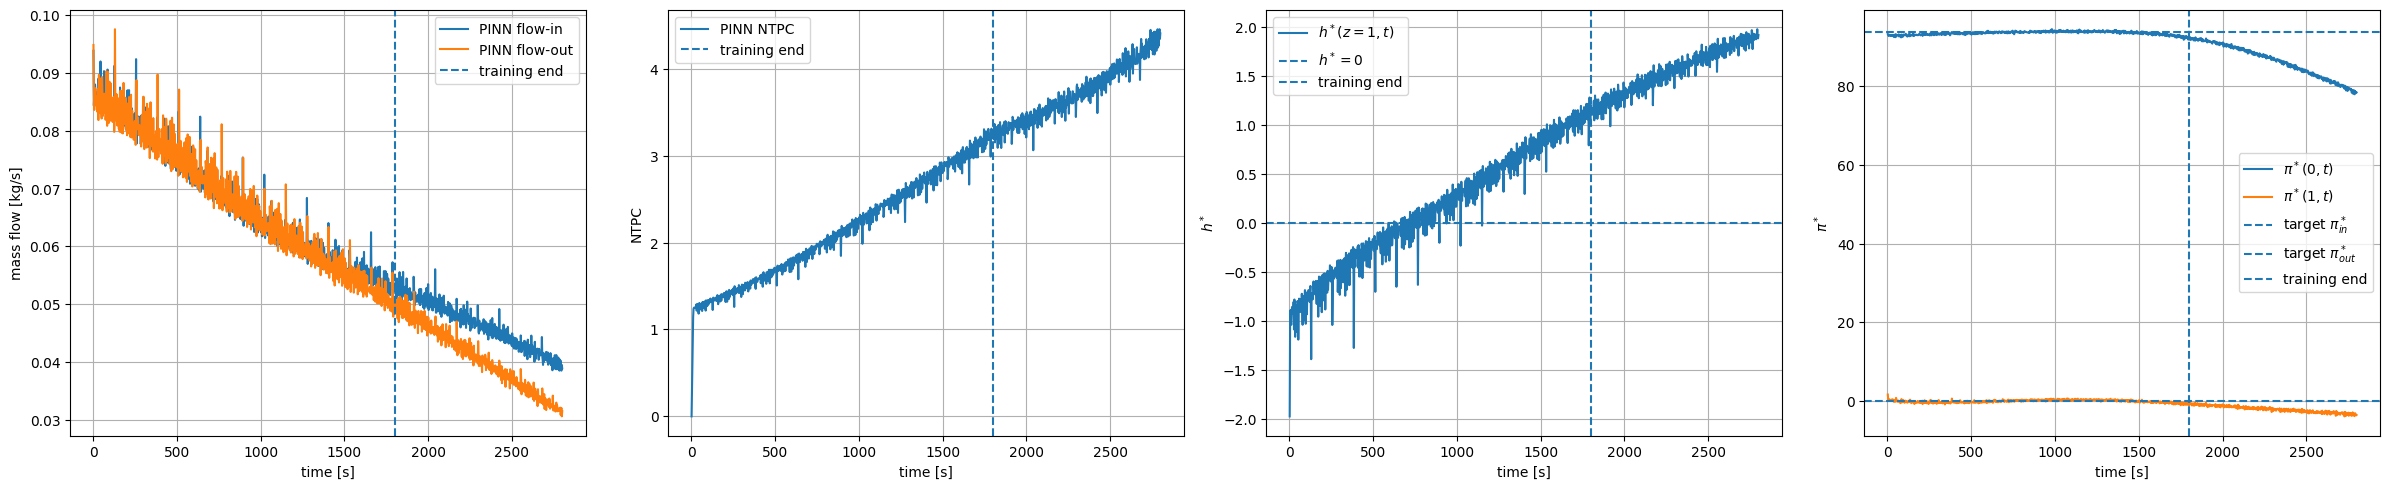

In [74]:
def plot_extended_observation(obs):
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    t_end = obs["original_time_end"]

    ax = axes[0]
    ax.plot(obs["time"], obs["flow_in"], label="PINN flow-in")
    ax.plot(obs["time"], obs["flow_out"], label="PINN flow-out")
    ax.axvline(t_end, linestyle="--", label="training end")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("mass flow [kg/s]")
    ax.grid(True)
    ax.legend()

    ax = axes[1]
    ax.plot(obs["time"], obs["ntpc"], label="PINN NTPC")
    ax.axvline(t_end, linestyle="--", label="training end")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("NTPC")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(obs["time"], obs["h_out"], label=r"$h^*(z=1,t)$")
    ax.axhline(0.0, linestyle="--", label=r"$h^*=0$")
    ax.axvline(t_end, linestyle="--", label="training end")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$h^*$")
    ax.grid(True)
    ax.legend()

    ax = axes[3]
    ax.plot(obs["time"], obs["pi_in"], label=r"$\pi^*(0,t)$")
    ax.plot(obs["time"], obs["pi_out"], label=r"$\pi^*(1,t)$")
    ax.axhline(case.dpi_star, linestyle="--", label=r"target $\pi^*_{in}$")
    ax.axhline(0.0, linestyle="--", label=r"target $\pi^*_{out}$")
    ax.axvline(t_end, linestyle="--", label="training end")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$\pi^*$")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_extended_observation(obs)